## Desigualdad en Salud Chilena: un estudio enfocado en las comunas y su acceso a hospitalizaciones complejas
Integrantes: Ignacia Castillo, Amalia Díaz, Juan Pablo Molina, María Poddubnaya <br>
<br>
Se busca estudiar la desigualdad en el acceso a hospitalización compleja. Para esto, se analizan egresos hospitalarios de la base de datos del GRD, enfocándonos en casos de alta complejidad, definidos como egresos con severidad 2 y 3 (Moderada y Mayor) y peso GRD > 2 (casos que cuesten el doble al promedio y más).
Además, para entender el impacto de la desigualdad en estos registros, se trabaja con los siguientes datasets:
- CIE-10 (tabla maestra de códigos de diagnósticos)
- Pobreza comunal 2024 (MINDESOF, índice pobreza multidimensional comunal)
- Base de Establecimientos 2024 (DIES, asocia código hospital con datos específicos)
- Dotación de camas hospitalarias (DIES, camas totales y camas criticas por año y establecimiento)
- Proyección de poblacion 2002-2035 (INE, versión 2017, obtener población 2018-2024 por comuna)

_Antes de comenzar, se menciona que si todo el código fue descargado de GitHub, no se encuentran los datasets como .xlsx o .csv/txt, debido a su tamaño, pero se incluye grd_procesado.parquet, que contiene los resultados finales, que se utilizan para realizar todo el análisis._<br>
<br>
Se importan librerías necesarias:

In [ ]:
import pandas as pd
import numpy as np
import time
import unicodedata

#### Cruce de datos: preparación
Luego, comienza la carga de bases de datos para cruzar. Primero, la del CIE-10, donde se utilizará el codigo (ej.: A12.30), presente en la base del GRD, para cruzar los datos y añadir la descripción y sección del diagnóstico (hay casi 40.000 diagnósticos diferentes).

In [ ]:
# se declaran las columnas a importar
cols_cie10 = ['Código', 'Descripción', 'Sección']
# lectura de datos
ruta = 'CIE-10.xlsx'
dtypes = {col:'string' for col in cols_cie10}
cie10 = pd.read_excel(ruta, usecols=cols_cie10, dtype=dtypes)

# se renombran columnas para calzar con el estilo del GRD
cie10.rename(columns={
    'Código':'DIAGNOSTICO1',
    'Descripción':'DESCRIPCION',
    'Sección':'SECCION'
    }, inplace=True)
# información básica sobre valores importados
cie10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39873 entries, 0 to 39872
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   DIAGNOSTICO1  39873 non-null  string
 1   DESCRIPCION   39873 non-null  string
 2   SECCION       39873 non-null  string
dtypes: string(3)
memory usage: 934.7 KB


Para la base de pobreza comunal 2024, se toma el índice de pobreza multidimensional por comuna, que es simplemente el porcentaje de población de la comuna viviendo en pobreza multidimensional (que considera Educación, Salud, Trabajo/Seguridad Social, Vivienda/Entorno y Redes/Cohesión Social)

In [ ]:
# se cargan datos del excel
ruta = 'sae_multidimensional_2024.xlsx'
dtypes_pm = {
    'Porcentaje de personas en situacion de pobreza multidimensional 2024':'float32',
    'Código':'string'
}
cols_pm = list(dtypes_pm.keys())
pm = pd.read_excel(ruta, header=2, usecols=cols_pm, dtype=dtypes_pm)
# se ajusta el codigo de comuna, para hacer match con el GRD
pm['Código'] = pm['Código'].str.strip().str.zfill(5)
# renombre de comunas para calzar con GRD
pm.rename(columns={
    'Porcentaje de personas en situacion de pobreza multidimensional 2024':'POB_MULTIDIM',
    'Código':'COD_COMUNA'
    }, inplace=True)
# pm['COMUNA_REGISTRADA'] = pm['COMUNA_REGISTRADA'].str.strip().str.upper().apply(remove_tildes)
pm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   COD_COMUNA    345 non-null    string 
 1   POB_MULTIDIM  345 non-null    float32
dtypes: float32(1), string(1)
memory usage: 4.2 KB


Con tal de poder trabajar a fondo con las comunas, dado el enfoque de nuestro trabajo, es importante poder estandarizar los nombres en cualquier dataset que contenga las comunas. En este caso, se utilizará la función de remover tildes y luego todas las comunas en mayúscula para hacer que calcen.

In [ ]:
def remove_tildes(text):
    return unicodedata.normalize("NFD", text).encode("ascii", "ignore").decode("utf-8")

Para el dataset de la base de establecimientos, se usa el código de la comuna como columna compartida, y se traen códigos de región y sus nombres, junto con datos clave de cada establecimiento de salud: ubicación, nivel de complejidad del establecimiento, etc.

In [ ]:
# se declara la ruta, columnas y sus dtypes (tipo de dato) para cargar excel
ruta = "Base de Establecimientos 2024.xlsx"
dtypes_estab = {'Código Vigente':'string',
        'Código Región':'str',
        'Nombre Región':'category',
        'Código Comuna':'str',
        'Nombre Comuna':'category',
        'Nombre Oficial':'string',
        'Tipo de Prestador Sistema de Salud': 'string',
        'Nivel de Complejidad': 'category',
        'LATITUD      [Grados decimales]':'float32',
        'LONGITUD [Grados decimales]':'float32',
        }
cols_estab = list(dtypes_estab.keys())
# se lee el excel y especifica que Pendiente es un valor nulo para la ubicacion
estab = pd.read_excel(ruta, header=1, usecols=cols_estab, dtype=dtypes_estab, 
                                na_values={"LATITUD      [Grados decimales]": "Pendiente",
                                "LONGITUD [Grados decimales]": "Pendiente"}, decimal=',')

# se asegura que los codigos sean string para modificarlos y que calcen con GRD
estab['Código Región'] = estab['Código Región'].astype('string')
estab['Código Comuna'] = estab['Código Comuna'].astype('string')
estab['Código Vigente'] = estab['Código Vigente'].astype('string')
# se renombran columnas para mantener estilo GRD
estab.rename(columns={
        "Código Vigente":"COD_ESTABLECIMIENTO",
        'Código Región':'COD_REGION',
        'Código Comuna':'COD_COMUNA',
        'Nombre Región':'REGION',
        'Nombre Comuna':'COMUNA',
        'Nombre Oficial':'ESTABLECIMIENTO',
        'Tipo de Prestador Sistema de Salud':'PRESTADOR',
        'Nivel de Complejidad':'COMPLEJIDAD_ESTAB',
        'LATITUD      [Grados decimales]':'LATITUD',
        'LONGITUD [Grados decimales]':'LONGITUD',
        }, inplace=True)
# se normalizan los codigos para tener 5 digitos, y si tienen 4, partir con un 0
estab['COMUNA'] = estab['COMUNA'].str.strip().str.upper().apply(remove_tildes)
estab['COD_COMUNA'] = estab['COD_COMUNA'].str.strip().str.zfill(5)
estab['PRESTADOR'] = estab['PRESTADOR'].str.strip()
estab['ESTABLECIMIENTO'] = estab['ESTABLECIMIENTO'].str.strip()
estab = estab.dropna().reset_index(drop=True)
display(estab.shape, estab.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4585 entries, 0 to 4584
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   COD_ESTABLECIMIENTO  4585 non-null   string  
 1   COD_REGION           4585 non-null   string  
 2   REGION               4585 non-null   category
 3   ESTABLECIMIENTO      4585 non-null   string  
 4   COD_COMUNA           4585 non-null   string  
 5   COMUNA               4585 non-null   object  
 6   LATITUD              4585 non-null   float32 
 7   LONGITUD             4585 non-null   float32 
 8   PRESTADOR            4585 non-null   string  
 9   COMPLEJIDAD_ESTAB    4585 non-null   category
dtypes: category(2), float32(2), object(1), string(5)
memory usage: 260.7+ KB


(4585, 10)

None

Luego, se importa un dataset complementario, que son las camas hospitalarias a los establecimientos. Este dataset y el anterior son AMBOS del DEIS, por lo que sus datos son similares y se importa con el mismo código como variable que une estos datasets.

In [ ]:
# nuevamente, se declara la ruta
ruta = 'Dotacion_Camas_Hospitalarias_2025.xlsx'
# esta vez, las columnas con la cantidad de camas tienen el año como nombre,
# se importan desde 2019-2024, para cruzar segun año
dtypes_camas = {
    'Código Establecimiento':'string',
    'Área Funcional':'string',
    **{year:'string' for year in range(2019,2025)}
}
cols_camas = list(dtypes_camas.keys())
# al importar, las columnas deben leerse con una funcion lambda, ya que al ser numeros no se leen correctamente
camas = pd.read_excel(ruta, header=2, dtype=dtypes_camas, usecols=lambda col: col in cols_camas)
# se renombran columnas para calzar con GRD
camas.rename(columns={
    year:f'{year}' for year in range(2019,2025)}, inplace=True)
camas.rename(columns={
    'Código Establecimiento':'COD_ESTABLECIMIENTO',
    'Área Funcional':'Area'
}, inplace=True)

# el formato del documento incluye codigos en una columna que representan a muchas filas,
# por lo que se realiza un forward fill para que se repita y sea posible agrupar luego
camas['COD_ESTABLECIMIENTO'] = camas['COD_ESTABLECIMIENTO'].ffill()
# camas = camas.dropna(
#     subset= ['COD_ESTABLECIMIENTO']
#     ).reset_index(drop=True)

# hay muchos tipos de cama, por lo que se guardan los totales por separado
totales = camas[camas['Area'] == 'Total'].copy()

# las camas criticas se agrupan, para considerarlas en una sola variable
camas_criticas = [
    'Área Cuidados Intensivos Adultos',
    'Área Cuidados Intermedios Adulto',
    'Área Cuidados Intensivos Pediátrica',
    'Área Cuidados Intermedios Pediátricos',
    'Área Neonatología Cuidados Intensivos',
    'Área Neonatología Cuidados Intermedios'
]
# se filtran datos para incluir estos valores en una variable aparte
criticas = camas[camas['Area'].isin(camas_criticas)].copy()
# se elimina columna de area, ahora innecesaria
totales = totales.drop(columns=['Area'])
criticas = criticas.drop(columns=['Area'])

# se convierten los datos a numeros, dejando valores vacios como 0
for year in range(2019,2025):
    criticas[f'{year}'] = pd.to_numeric(criticas[f'{year}'], errors='coerce')
    totales[f'{year}'] = pd.to_numeric(totales[f'{year}'], errors='coerce')
    criticas[f'{year}'] = criticas[f'{year}'].fillna(0).astype('UInt16')
    totales[f'{year}'] = totales[f'{year}'].fillna(0).astype('UInt16')
cols_camas_str = [f'{year}' for year in range(2019,2025)]

# se agrupan las camas criticas para que quede la suma de ellas por cada establecimiento
criticas = pd.DataFrame(criticas.groupby('COD_ESTABLECIMIENTO', as_index=False).sum())
# como hay datos de muchos años, para poder cruzar los datos considerando los años, es necesario
# que sean parte de las filas, con una columna unica de año, por lo que se hace melt de los datos
criticas = criticas.melt(
    id_vars='COD_ESTABLECIMIENTO',
    value_vars=cols_camas_str,
    var_name='YEAR',
    value_name='CAMAS_CRITICAS'
)
# lo mismo para las camas totales, dejando todos los años en una sola columna
totales = totales.melt(
    id_vars='COD_ESTABLECIMIENTO',
    value_vars=cols_camas_str,
    var_name='YEAR',
    value_name='CAMAS_TOTALES'
)
# finalmente, se cruzan los datos de camas criticas y totales, para cargar datos de camas por establecimiento
camas = pd.merge(totales, criticas, on=['COD_ESTABLECIMIENTO','YEAR'], how='left')
camas['CAMAS_CRITICAS'] = camas['CAMAS_CRITICAS'].fillna(0)
camas['YEAR'] = camas['YEAR'].astype('int32')
display(camas.info(), camas.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1182 entries, 0 to 1181
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   COD_ESTABLECIMIENTO  1182 non-null   string
 1   YEAR                 1182 non-null   int32 
 2   CAMAS_TOTALES        1182 non-null   UInt16
 3   CAMAS_CRITICAS       1182 non-null   UInt16
dtypes: UInt16(2), int32(1), string(1)
memory usage: 20.9 KB


None

,COD_ESTABLECIMIENTO,YEAR,CAMAS_TOTALES,CAMAS_CRITICAS
0,101100,2019,313,38
1,102100,2019,440,60
2,201319,2019,0,0
3,103103,2019,40,0
4,103104,2019,10,0


Para el último dataset a cruzar, se tiene la proyección de población por año, a nivel de comuna, provincia o región dado por el INE en 2017. Se utilizará para contar con valores de población específicos según el año de egreso hospitalario GRD.

In [ ]:
# se cargan region, comuna y años, donde está el valor de la población
ruta = 'Proyeccion_2002-2035_Comunas.xlsx'
# similarmente a las camas, se consideran años 2019-2024
dtypes_pob = {
    'Region':'string',
    'Comuna':'string',
    **{f'Poblacion {year}':'uint16' for year in range(2019,2025)}
}
cols_pob = list(dtypes_pob.keys())
# se lee el excel con columnas establecidas
poblacion = pd.read_excel(ruta, usecols=cols_pob, dtype=dtypes_pob)
# igual que con las camas, se necesita esta información según año en UNA sola columna,
# por lo que se hace un melt de los datos, enfocandose en los años.
poblacion = poblacion.melt(
    id_vars=['Region','Comuna'],
    value_vars=[f'Poblacion {year}' for year in range(2019,2025)],
    var_name='YEAR',
    value_name='Poblacion'
)
# dentro del valor del año, se remueve la palabra población, dejando solo el valor numérico
poblacion['YEAR'] = poblacion['YEAR'].str.replace('Poblacion ', '').astype('int32')
# se agrupan valores según region, comuna, y año primero, en variable aparte
comunas = poblacion.groupby(
    by=['Region','Comuna','YEAR'],
    observed=True
    )['Poblacion'].sum().reset_index() # y se calcula la suma, en este caso es comunal
comunas.rename(columns={'Poblacion':'POB_COMUNA'}, inplace=True)

# se hace el mismo proceso, pero ahora solo con la región, para contar con ambos datos
regiones = comunas.groupby(
    by=['Region','YEAR'],
    observed=True
    )['POB_COMUNA'].sum().reset_index() # se obtienen totales regionales de población, por año
regiones.rename(columns={'POB_COMUNA':'POB_REGION'}, inplace=True)

# finalmente, se unen estas dos variables separadas, para tener un solo DataFrame con toda la información
poblacion = pd.merge(
    comunas, 
    regiones, 
    on=['Region','YEAR'],
    how='left'
)
# igual que antes, se rellena el codigo con 0s en caso de no tener 5 digitos, para cruzar con GRD
poblacion['Comuna'] = poblacion['Comuna'].str.strip().str.zfill(5)
poblacion.rename(columns={'Comuna':'COD_COMUNA', 'Region':'COD_REGION'}, inplace=True)
display(poblacion.head(), poblacion.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2076 entries, 0 to 2075
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   COD_REGION  2076 non-null   string
 1   COD_COMUNA  2076 non-null   string
 2   YEAR        2076 non-null   int32 
 3   POB_COMUNA  2076 non-null   uint64
 4   POB_REGION  2076 non-null   uint64
dtypes: int32(1), string(2), uint64(2)
memory usage: 73.1 KB


,COD_REGION,COD_COMUNA,YEAR,POB_COMUNA,POB_REGION
0,1,01101,2019,216514,368906
1,1,01101,2020,223463,382773
2,1,01101,2021,227127,391165
3,1,01101,2022,229072,396697
4,1,01101,2023,230595,401588


None

Ahora, se realiza un proceso un poco más largo para cargar la base de datos GRD, que contempla desde los años 2019 al 2024, y cambios año a año, por lo que se utilizan ciertas funciones que faciliten el proceso y logren consolidar toda la información en un único dataset.

In [ ]:
# codificaciones del texto a intentar, dado que hubo problemas al usar utf-8 o latin inicialmente
ENCODINGS_TO_TRY = ['utf-8-sig', 'utf-16', 'utf-8', 'cp1252', 'latin1']
# se probara primero leer algunos caracteres y revisar la codificación, y en caso de haber error
# intentar la siguiente
def detect_encoding(filepath):
    for enc in ENCODINGS_TO_TRY:
        try:
            with open(filepath, 'r', encoding=enc) as f:
                f.read(8192)
            return enc
        except (UnicodeDecodeError, UnicodeError):
            continue
    return 'latin1'  # en caso de que todo falle, se ocupa una confiable
# se incluyen todas las variables a cargar para el GRD, y sus dtypes
dtypes_grd = {'COD_HOSPITAL':"string", 
        'CIP_ENCRIPTADO':'string',
        'SEXO':"category",
        'PREVISION':"category",
        'COMUNA':"category",
        'PROVINCIA':"category",
        'TIPOALTA':"category",
        'SERVICIO_SALUD':"category",
        'TIPO_PROCEDENCIA':"category",
        'TIPO_INGRESO':"category",
        **{f'DIAGNOSTICO{i}':"string" for i in range(1,36)},
        **{f'PROCEDIMIENTO{i}':"string" for i in range(1,31)},
        'IR_29301_COD_GRD':'string',
        'IR_29301_PESO':'string',
        'IR_29301_SEVERIDAD':"category",
        'IR_29301_MORTALIDAD':"category"
        }

target_cols = list(dtypes_grd.keys())
# estas columnas especificas contienen fechas, se usaran luego
cols_fechas = ['FECHA_NACIMIENTO', 'FECHA_INGRESO', 'FECHAALTA']
target_cols.extend(cols_fechas)
# se utiliza un diccionario con parametros clave para la carga del grd en pd.read_csv()
config_carga = {
        # con prueba y error, se descubre que el separador es "|" para cada archivo .txt de GRD
        "sep": "|",
        # se leeran fechas con su dtype apropiado segun columnas antes establecidas
        "parse_dates": cols_fechas,
        # con muchos datos, se especifica una opción de memoria
        "low_memory":False,
        # columnas objetivo
        "usecols": target_cols,
        # en caso de haber lineas con errores, saltarlas
        "on_bad_lines": "skip",
        # tipo de datos
        "dtype": dtypes_grd,
}

Luego, se importan los archivos de cada año, registrando tiempos de carga.

In [ ]:
# cada uno de los grd, segun el año, se guardará en este diccionario
grds = {}
# comienza la carga de todos los datos
for year in range(2019,2025):
    print(f'abriendo grd{year}...')
    # se leen los parametros
    params = config_carga.copy()
    # y las columnas a cargar
    cols = target_cols.copy()
    # se especifica la ruta segun el año
    ruta = f"GRD_PUBLICO_{year}.txt"
    # y la codificación más probable según la funcion
    encoding = detect_encoding(ruta)
    # se registra el tiempo de carga, solo por motivos informativos
    inicio = time.time()
    # para 2024, la columna del rut encriptado cambia de nombre, por lo que se considera
    if year == 2024:
        cols[1] = 'ID_BENEFICIARIO'
        params['usecols'] = cols
    # se lee el archivo
    grds[f'grd{year}'] = pd.read_csv(ruta, encoding = encoding, **params)
    # y se registra tiempo de finalizacion
    final = time.time()
    # para informar de carga 
    print(f'carga de grd{year} en {final-inicio:.3f}s\n')

abriendo grd2019...
carga de grd2019 en 17.523s

abriendo grd2020...
carga de grd2020 en 9.718s

abriendo grd2021...
carga de grd2021 en 11.060s

abriendo grd2022...
carga de grd2022 en 14.219s

abriendo grd2023...


/tmp/ipykernel_9157/1221887794.py:21: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  grds[f'grd{year}'] = pd.read_csv(ruta, encoding = encoding, **params)


carga de grd2023 en 13.933s

abriendo grd2024...
carga de grd2024 en 14.778s



Una vez cargados, es necesario estandarizar las fechas y juntarlos en un solo dataset.

In [ ]:
# se estandariza la fecha de 2023, que tiene ciertas columnas con dias primero
grds['grd2023']['FECHAALTA'] = pd.to_datetime(grds['grd2023']['FECHAALTA'], dayfirst=True, errors='coerce')
grds['grd2023']['FECHA_INGRESO'] = pd.to_datetime(grds['grd2023']['FECHA_INGRESO'], dayfirst=True, errors='coerce')
# se renombra la columna modificada en 2024 al nombre antiguo
grds['grd2024'].rename(columns={"ID_BENEFICIARIO":"CIP_ENCRIPTADO"}, inplace=True)
# se unen los datasets de todos los años, tras estandarizar los formatos
grd = pd.concat(grds.values(), ignore_index=True)
# se pasan las columnas a dtype datetime64
for col in cols_fechas:
    grd[col] = pd.to_datetime(grd[col], errors='coerce')

Después, se apunta a ciertas columnas con problemas. En este caso, el peso GRD representa una proporción de costo del egreso según promedio. Por ejemplo, una estadía que cuesta el triple que el promedio, tiene un peso GRD de 3, una que cuesta el promedio es peso 1, y una que cuesta la mitad tiene un valor de 0.5. Al revisar un poco los datos, se encuentran muchos valores como 12812, 23319, 14012, en los que los costos no tendrían sentido, con no solo una persona costando 20 mil veces mas que el promedio, sino múltiples. Se asume que es un error de tipeo/carga/lectura de datos, y que deberían tener una coma. Existe la posibilidad de GRDs que sean mayor a 10, por lo que 14012 -> 1.4012 o 14.012 son ambos válidos. En este caso, se asumió, para simplificar el problema, que tienen la coma al principio, tal que: 14012 -> 1.4012, aunque se entiende que esto introduce un posible sesgo.

In [ ]:
# se lee el rut encriptado como dtype string, para que no se considere un
# numero y aparezca en las estadisticas erroneamente
grd['CIP_ENCRIPTADO'] = grd['CIP_ENCRIPTADO'].astype('string')

# se cambia la coma por punto para interpretar como float
grd['IR_29301_PESO'] = grd.IR_29301_PESO.str.replace(',','.', regex=False)
# los que NO tienen punto
dec_coma = ~grd['IR_29301_PESO'].str.contains('.', regex=False)
# todos como float
floats = pd.to_numeric(grd['IR_29301_PESO'], errors='coerce')
# grd['IR_29301_PESO'] = grd.IR_29301_PESO.str.replace('.','')
powers = np.maximum(grd['IR_29301_PESO'].str.len() - 1,1)
# se divide solo donde no hay punto, por error de tipeo
grd['IR_29301_PESO'] = np.where(dec_coma, floats / (10 ** powers), floats)

# columnas categoricas, que guardan valores unicos, o categorias de pandas
categ_cols = ['SEXO', 'PREVISION', 'TIPO_PROCEDENCIA', 'TIPO_INGRESO', 'IR_29301_SEVERIDAD', 'IR_29301_MORTALIDAD',
            'TIPOALTA', 'PROVINCIA', 'COMUNA','SERVICIO_SALUD']
# columnas de diagnosticos y procedimientos
diag_cols = [f'DIAGNOSTICO{i}' for i in range(2,36)]
proced_cols = [f'PROCEDIMIENTO{i}' for i in range(1,31)]
# se eliminan nulos tras estandarizar la mayoria de columnas
cols_ignore = diag_cols + proced_cols
grd = grd.dropna(subset=[col for col in grd.columns if col not in cols_ignore])
# se transforman las columnas anteriores a categoricas
grd = grd.astype({col: 'category' for col in categ_cols})
# se reescriben ciertos nombres de columna para calzar con los merges proximos
grd.rename(columns={'COMUNA':'COMUNA_REGISTRADA', 'COD_HOSPITAL':'COD_ESTABLECIMIENTO'}, inplace=True)
# se filtran datos para que solo sean con fecha ingreso >= 2019
grd['YEAR'] = grd['FECHA_INGRESO'].dt.year
grd['YEAR'] = grd['YEAR'].astype('int32')
grd = grd[grd['YEAR'] >= 2019]
grd.reset_index(drop=True, inplace=True)

# se estandarizan las comunas para que la registrada y del establecimiento
# esten escritas de la misma manera y puedan compararse
grd['COMUNA_REGISTRADA'] = grd['COMUNA_REGISTRADA'].str.strip().str.upper().apply(remove_tildes)
grd['COMUNA_REGISTRADA'] = grd['COMUNA_REGISTRADA'].str.replace('COIHAIQUE','COYHAIQUE')
grd['COMUNA_REGISTRADA'] = grd['COMUNA_REGISTRADA'].str.replace('AISEN','AYSEN')
grd['COMUNA_REGISTRADA'] = grd['COMUNA_REGISTRADA'].str.replace('CON CON','CONCON')
grd['COMUNA_REGISTRADA'] = grd['COMUNA_REGISTRADA'].str.replace('O"HIGGINS','OHIGGINS')

# se crean variables clave, edad y dias estancia
grd['EDAD'] = ((grd['FECHA_INGRESO'] - grd['FECHA_NACIMIENTO']).dt.days / 365.25).round(1)
grd['DIAS_ESTANCIA'] = (grd['FECHAALTA'] - grd['FECHA_INGRESO']).dt.days
# se arreglan ciertas columnas y sus tipos de dato
grd['IR_29301_SEVERIDAD'] = grd.IR_29301_SEVERIDAD.astype('string').astype('category')

# para los diagnosticos, los 'DESCONOCIDO' se reemplazan con nulo, asumiendo que esto reduce
# el numero de diagnosticos en una cantidad reducida de pacientes
for col in diag_cols:
    grd[col] = grd[col].astype('string')
    grd[col].replace({'DESCONOCIDO':np.nan})
    grd[col] = grd[col].astype('category')
# se cuenta la cantidad total de comorbilidades y no. de procedimientos, para añadirlos
# como variable al dataset
grd['N_COMORBILIDADES'] = grd[diag_cols].count(axis=1)
grd['N_PROCEDIMIENTOS'] = grd[proced_cols].count(axis=1)

El índice de comorbilidad de Charlson va más allá de contar la cantidad de comorbilidades, sino que le da un peso a cada una según su mortalidad a largo plazo. Se incluye el diccionario que mapea pesos a diagnósticos aquí abajo, para poder introducir esta variable al dataset (crédito a Oscar Pichumán por compartir el código para este índice).

In [ ]:
# ================================================================
# ÍNDICE DE COMORBILIDAD DE CHARLSON — IMPLEMENTACIÓN PROPIA
# Referencia: Quan et al. (2011) Med Care, 49(6), 612–617.
#             Charlson et al. (1987) J Chronic Dis, 40(5), 373–383.
# ================================================================

# Mapeamos prefijos ICD-10 (3 caracteres) a la categoría Charlson.
# Cada categoría tiene un peso según el modelo original de Charlson
# actualizado por Quan et al. (2011).

CHARLSON_ICD10 = {
    # ── Peso 1 ──────────────────────────────────────────────
    # Infarto agudo de miocardio
    'I21': ('MI', 1), 'I22': ('MI', 1), 'I25': ('MI', 1),
    # Insuficiencia cardíaca congestiva
    'I50': ('CHF', 1),
    # Enfermedad vascular periférica
    'I70': ('PVD', 1), 'I71': ('PVD', 1), 'I73': ('PVD', 1),
    'I77': ('PVD', 1), 'I79': ('PVD', 1),
    # Enfermedad cerebrovascular
    'G45': ('CVD', 1), 'G46': ('CVD', 1),
    'I60': ('CVD', 1), 'I61': ('CVD', 1), 'I62': ('CVD', 1),
    'I63': ('CVD', 1), 'I64': ('CVD', 1), 'I65': ('CVD', 1),
    'I66': ('CVD', 1), 'I67': ('CVD', 1), 'I68': ('CVD', 1),
    'I69': ('CVD', 1),
    # Demencia
    'F00': ('DEM', 1), 'F01': ('DEM', 1), 'F02': ('DEM', 1),
    'F03': ('DEM', 1), 'G30': ('DEM', 1), 'G31': ('DEM', 1),
    # Enfermedad pulmonar crónica (EPOC)
    'J40': ('COPD', 1), 'J41': ('COPD', 1), 'J42': ('COPD', 1),
    'J43': ('COPD', 1), 'J44': ('COPD', 1), 'J45': ('COPD', 1),
    'J46': ('COPD', 1), 'J47': ('COPD', 1), 'J60': ('COPD', 1),
    'J61': ('COPD', 1), 'J62': ('COPD', 1), 'J63': ('COPD', 1),
    'J64': ('COPD', 1), 'J65': ('COPD', 1), 'J66': ('COPD', 1),
    'J67': ('COPD', 1),
    # Enfermedad del tejido conectivo
    'M05': ('RHD', 1), 'M06': ('RHD', 1), 'M32': ('RHD', 1),
    'M33': ('RHD', 1), 'M34': ('RHD', 1), 'M35': ('RHD', 1),
    # Úlcera péptica
    'K25': ('PUD', 1), 'K26': ('PUD', 1), 'K27': ('PUD', 1),
    'K28': ('PUD', 1),
    # Enfermedad hepática leve
    'B18': ('MLD', 1), 'K70': ('MLD', 1), 'K71': ('MLD', 1),
    'K73': ('MLD', 1), 'K74': ('MLD', 1), 'K76': ('MLD', 1),
    # Diabetes sin complicación
    'E10': ('DM', 1), 'E11': ('DM', 1), 'E12': ('DM', 1),
    'E13': ('DM', 1), 'E14': ('DM', 1),

    # ── Peso 2 ──────────────────────────────────────────────
    # Hemiplejia
    'G04': ('HEMI', 2), 'G81': ('HEMI', 2), 'G82': ('HEMI', 2),
    'G83': ('HEMI', 2),
    # Enfermedad renal moderada/severa
    'N03': ('REN', 2), 'N05': ('REN', 2), 'N18': ('REN', 2),
    'N19': ('REN', 2), 'N25': ('REN', 2),
    # Diabetes con complicación crónica
    'E102': ('DMC', 2), 'E112': ('DMC', 2), 'E122': ('DMC', 2),
    'E132': ('DMC', 2), 'E142': ('DMC', 2),
    # Tumor sólido sin metástasis
    'C00': ('TUM', 2), 'C01': ('TUM', 2), 'C02': ('TUM', 2),
    'C03': ('TUM', 2), 'C04': ('TUM', 2), 'C05': ('TUM', 2),
    'C06': ('TUM', 2), 'C07': ('TUM', 2), 'C08': ('TUM', 2),
    'C09': ('TUM', 2), 'C10': ('TUM', 2), 'C11': ('TUM', 2),
    'C12': ('TUM', 2), 'C13': ('TUM', 2), 'C14': ('TUM', 2),
    'C15': ('TUM', 2), 'C16': ('TUM', 2), 'C17': ('TUM', 2),
    'C18': ('TUM', 2), 'C19': ('TUM', 2), 'C20': ('TUM', 2),
    'C21': ('TUM', 2), 'C22': ('TUM', 2), 'C23': ('TUM', 2),
    'C24': ('TUM', 2), 'C25': ('TUM', 2), 'C26': ('TUM', 2),
    'C30': ('TUM', 2), 'C31': ('TUM', 2), 'C32': ('TUM', 2),
    'C33': ('TUM', 2), 'C34': ('TUM', 2), 'C37': ('TUM', 2),
    'C38': ('TUM', 2), 'C39': ('TUM', 2), 'C40': ('TUM', 2),
    'C41': ('TUM', 2), 'C43': ('TUM', 2), 'C45': ('TUM', 2),
    'C46': ('TUM', 2), 'C47': ('TUM', 2), 'C48': ('TUM', 2),
    'C49': ('TUM', 2), 'C50': ('TUM', 2), 'C51': ('TUM', 2),
    'C52': ('TUM', 2), 'C53': ('TUM', 2), 'C54': ('TUM', 2),
    'C55': ('TUM', 2), 'C56': ('TUM', 2), 'C57': ('TUM', 2),
    'C58': ('TUM', 2), 'C60': ('TUM', 2), 'C61': ('TUM', 2),
    'C62': ('TUM', 2), 'C63': ('TUM', 2), 'C64': ('TUM', 2),
    'C65': ('TUM', 2), 'C66': ('TUM', 2), 'C67': ('TUM', 2),
    'C68': ('TUM', 2), 'C69': ('TUM', 2), 'C70': ('TUM', 2),
    'C71': ('TUM', 2), 'C72': ('TUM', 2), 'C73': ('TUM', 2),
    'C74': ('TUM', 2), 'C75': ('TUM', 2), 'C76': ('TUM', 2),
    'C97': ('TUM', 2),
    # Leucemia
    'C91': ('LEU', 2), 'C92': ('LEU', 2), 'C93': ('LEU', 2),
    'C94': ('LEU', 2), 'C95': ('LEU', 2),
    # Linfoma
    'C81': ('LYM', 2), 'C82': ('LYM', 2), 'C83': ('LYM', 2),
    'C84': ('LYM', 2), 'C85': ('LYM', 2), 'C88': ('LYM', 2),
    'C90': ('LYM', 2),

    # ── Peso 3 ──────────────────────────────────────────────
    # Enfermedad hepática moderada/severa
    'K70': ('MSLD', 3), 'K72': ('MSLD', 3), 'K76': ('MSLD', 3),

    # ── Peso 6 ──────────────────────────────────────────────
    # Tumor sólido con metástasis
    'C77': ('METS', 6), 'C78': ('METS', 6),
    'C79': ('METS', 6), 'C80': ('METS', 6),
    # VIH / SIDA
    'B20': ('AIDS', 6), 'B21': ('AIDS', 6),
    'B22': ('AIDS', 6), 'B24': ('AIDS', 6),
}

print(f"Mapa Charlson cargado: {len(CHARLSON_ICD10)} prefijos ICD-10 mapeados")
print(f"Categorías únicas: {len(set(v[0] for v in CHARLSON_ICD10.values()))}")
indice_charlson = {key:val[1] for key,val in CHARLSON_ICD10.items()}

Mapa Charlson cargado: 169 prefijos ICD-10 mapeados
Categorías únicas: 19


In [ ]:
results = []
for col in diag_cols:
    result = grd[col].str[:3].map(indice_charlson).fillna(0)
    results.append(result)
grd['INDICE_CHARLSON'] = pd.concat(results, axis=1).sum(axis=1)

In [ ]:
# con un enfoque alejado de los diagnosticos y procedimientos particulares, se deja la
# mínima cantidad de columnas para estos valores
grd.drop(columns=(diag_cols[2:] + proced_cols[2:]), inplace=True)

Para guardar espacio, la librería de pandas tiene un tipo de archivo de terminación .parquet, que pesa menos y se lee mucho más rápido que cargar todos los CSV/TXT cada vez (indirectamente reduce la memoria RAM utilizada, dado que se carga el archivo final, y no todos los intermedios y sus variables asociadas, que pueden seguir consumiendo memoria).

In [ ]:
# esto resulta en un archivo, dentro del mismo directorio actual, con el nombre 'grd_19-24.parquet'
grd.to_parquet('grd_19-24.parquet')

En caso de querer continuar desde acá el notebook, se puede cerrar (lo que borra las variables cargadas hasta el momento) y continuar desde aquí, ya que se guarda el dataset (_no se incluye en GitHub debido al peso_)

In [ ]:
# import pandas as pd
# grd = pd.read_parquet('grd_19-24.parquet')

Como nuestro enfoque es en el acceso a hospitalización compleja, se filtran datos, considerando severidad moderada y mayor, o 2 y 3, y un peso grd mayor a 2.

In [ ]:
# se consideran casos de peso > 2 y severidad 2 o 3, quedando con 6.4% del dataset
grd = grd[grd['IR_29301_PESO'] > 2]
grd = grd[(grd['IR_29301_SEVERIDAD'] == '2') | (grd['IR_29301_SEVERIDAD'] == '3')]
grd = grd.reset_index(drop=True)

Nuevamente, se guarda el archivo como parquet esta vez filtrado, y es posible empezar el código desde aquí, sin tener que cargar todos los archivos de nuevo.

In [ ]:
grd.to_parquet('grd_ac_19-24.parquet')

(_No se cuenta con este archivo en el repositorio de GitHub_)

In [ ]:
# import pandas as pd
# grd = pd.read_parquet('grd_ac_19-24.parquet')

Se realiza el cruce de cada dataset secundario con el GRD ya procesado y filtrado. Se renombran ciertas columnas y añaden variables clave utilizando esta nueva información.

In [ ]:
# se realizan todos los merge para los que se preparo la base de grd
# merge con cie10.
grd = pd.merge(grd, cie10, on='DIAGNOSTICO1', how='left')
# merge con base establecimientos
grd = pd.merge(grd, estab, on='COD_ESTABLECIMIENTO',how='left')
# merge con proyeccion poblacion del INE
grd = pd.merge(grd, poblacion, on=['COD_REGION','COD_COMUNA','YEAR'], how='left')
# merge con camas hospitalarias por establecimiento
grd = pd.merge(grd, camas, on=['COD_ESTABLECIMIENTO','YEAR'], how='left')
# merge con indice pobreza multidimensional
grd = pd.merge(grd, pm, on='COD_COMUNA', how='left')
# se cambian ciertos nombres para ser mas descriptivos
grd.rename(columns={'COMUNA':'COMUNA_ESTAB', 'POB_MULTIDIM':'POB_MULT_ESTAB'}, inplace=True)
# la pobreza multidimensional tiene unos pocos valores vacios, se rellenan con la media
grd['POB_MULT_ESTAB'] = grd['POB_MULT_ESTAB'].fillna(grd['POB_MULT_ESTAB'].mean())
# se crea la variable booleana: comuna con establecimiento de alta complejidad (1/0 para si/no)
grd['COMUNA_CON_ESTAB_AC'] = grd['COMUNA_REGISTRADA'].isin(grd['COMUNA_ESTAB']).astype(int)
# variable fallecido es otra booleana que marca con 1 a pacientes fallecidos
grd["FALLECIDO"] = (grd["TIPOALTA"] == "FALLECIDO").astype(int)
# proporcion de camas criticas para cada establecimiento, respecto a camas totales
grd['CRITICAS_PROP'] = grd['CAMAS_CRITICAS'] / grd['CAMAS_TOTALES']
# se busca calcular la cantidad de camas según 1000 habitantes, por comuna. al haber diferentes
# poblaciones para la misma comuna en diferentes años, es necesario aislar estos datos por separado
estab_unicos_comuna = grd.drop_duplicates(subset=['COMUNA_ESTAB','COD_ESTABLECIMIENTO','YEAR'])
# se agrupa por comuna y año, lo que deja a varios establecimientos por comuna en cada grupo
comunas_unique = estab_unicos_comuna.groupby(['COMUNA_ESTAB','YEAR'],observed=True)
# se suman las camas de cada establecimiento, para cada grupo de comuna-año
camas_comuna = comunas_unique['CAMAS_TOTALES'].sum().reset_index(name='CAMAS_COMUNA')
# lo mismo para las camas criticas
criticas_comuna = comunas_unique['CAMAS_CRITICAS'].sum().reset_index(name='CRITICAS_COMUNA')
# se unen todos estos datos al grd, para tener las variables deseadas
grd = grd.merge(camas_comuna, on=['COMUNA_ESTAB','YEAR'], how='left')
grd = grd.merge(criticas_comuna, on=['COMUNA_ESTAB','YEAR'], how='left')
grd['CAMAS_1000HAB'] = grd['CAMAS_COMUNA']/grd['POB_COMUNA'] * 1000
grd['CRITICAS_1000HAB'] = grd['CRITICAS_COMUNA']/grd['POB_COMUNA'] * 1000
# se añade la tasa de mortalidad por comuna, calculada rapidamente con el promedio, ya que
# se utiliza la variable de 0 y 1 de fallecido, anteriormente creada
tasa_mortalidad_comuna = grd.groupby('COMUNA_ESTAB', observed=True)['FALLECIDO'].mean()
grd['TASA_MORTALIDAD_COMUNA'] = grd['COMUNA_ESTAB'].map(tasa_mortalidad_comuna)
# se transforman los dtypes de las nuevas columnas de poblacion
grd['POB_COMUNA'] = grd['POB_COMUNA'].astype('int32')
grd['POB_REGION'] = grd['POB_REGION'].astype('int32')
# se dropean nulos tras merge
grd = grd = grd.dropna(subset=[col for col in grd.columns if col not in cols_ignore]).reset_index(drop=True)
# se establecen ciertas variables categoricas que guardan espacio y reducen consumo ram del dataframe
categ_cols = ['COD_ESTABLECIMIENTO', 'COD_COMUNA','COD_REGION','YEAR','COMUNA_REGISTRADA']
for col in categ_cols:
    grd[col] = grd[col].astype('category')
# se muestra resultado final
display(grd.shape, grd.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367895 entries, 0 to 367894
Data columns (total 52 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   COD_ESTABLECIMIENTO     367895 non-null  category      
 1   CIP_ENCRIPTADO          367895 non-null  string        
 2   SEXO                    367895 non-null  category      
 3   FECHA_NACIMIENTO        367895 non-null  datetime64[ns]
 4   PROVINCIA               367895 non-null  category      
 5   COMUNA_REGISTRADA       367895 non-null  category      
 6   PREVISION               367895 non-null  category      
 7   SERVICIO_SALUD          367895 non-null  category      
 8   TIPO_PROCEDENCIA        367895 non-null  category      
 9   TIPO_INGRESO            367895 non-null  category      
 10  FECHA_INGRESO           367895 non-null  datetime64[ns]
 11  FECHAALTA               367895 non-null  datetime64[ns]
 12  TIPOALTA                367895

(367895, 52)

None

Se guarda el resultado final como parquet, lo que facilita analizar este archivo rápidamente en el futuro.

In [ ]:
grd.to_parquet("grd_procesado.parquet")

_Al descargar / clonar de GitHub, descomentar y empezar análisis desde el siguiente bloque, donde se tiene acceso al DataFrame final, ya cruzado y procesado._

In [ ]:
# grd = pd.read_parquet('grd_procesado.parquet)

## Análisis del GRD para la desigualdad de acceso a hospitalización compleja

Utilizando la base de datos del GRD cruzada con: Base de Establecimientos (DIES), Camas Hospitalarias (DIES), Proyección de población del INE, CIE10 (diagnósticos) y estimación de la pobreza multidimensional (BIDAT), se realizará un análisis exploratorio de las variables clave:

In [17]:
import pandas as pd
from charset_normalizer import from_bytes
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob as gb

Primero, se entiende la estructura de nuestra base, conociendo sus variables, los tipos de datos que contiene, la cantidad de filas y columnas, etc.

In [3]:
# Verificamos si hay valores nulos o faltantes
print("Valores nulos por columna:")
print(grd.isnull().sum())

# Verificamos valores únicos en algunas columnas clave
print("\nValores únicos en columna SEXO:")
print(grd['SEXO'].unique())

# print("\nValores únicos en columna TIPOALTA:")
# print(grd['TIPOALTA'].unique())

print("\nValores unicos de severidad")
print(grd['IR_29301_SEVERIDAD'].unique())

print("--- df.head() ---")
display(grd.head())          # primeras 5 filas

print("\n--- df.shape ---")
print(grd.shape)            

print("\n--- df.info() ---")
grd.info()                   # tipos + nulos

print("\n--- df.describe() ---")
display(grd.describe())                    # estadísticas numéricas

print("\n--- df.describe(include='all') ---")
display(grd.describe(include="all"))       # incluye categóricas

Valores nulos por columna:
COD_ESTABLECIMIENTO       0
CIP_ENCRIPTADO            0
SEXO                      0
FECHA_NACIMIENTO          0
PROVINCIA                 0
                         ..
CAMAS_COMUNA              0
CRITICAS_COMUNA           0
CAMAS_1000HAB             0
CRITICAS_1000HAB          0
TASA_MORTALIDAD_COMUNA    0
Length: 87, dtype: int64

Valores únicos en columna SEXO:
['HOMBRE', 'MUJER', 'DESCONOCIDO']
Categories (3, object): ['DESCONOCIDO', 'HOMBRE', 'MUJER']

Valores unicos de severidad
['2', '3']
Categories (4, object): ['0', '1', '2', '3']
--- df.head() ---


,COD_ESTABLECIMIENTO,CIP_ENCRIPTADO,SEXO,FECHA_NACIMIENTO,PROVINCIA,COMUNA_REGISTRADA,PREVISION,SERVICIO_SALUD,TIPO_PROCEDENCIA,TIPO_INGRESO,...,CAMAS_CRITICAS,POB_MULT_ESTAB,COMUNA_CON_ESTAB_AC,FALLECIDO,CRITICAS_PROP,CAMAS_COMUNA,CRITICAS_COMUNA,CAMAS_1000HAB,CRITICAS_1000HAB,TASA_MORTALIDAD_COMUNA
0,118100,467373,HOMBRE,1969-09-10,CONCEPCION,SAN PEDRO DE LA PAZ,FONASA INSTITUCIONAL - (MAI) B,CONCEPCIÓN,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,...,113,0.090303,0,0,0.128118,882,113,3.717488,0.476277,0.117963
1,118100,562854,HOMBRE,1956-02-07,CONCEPCION,CORONEL,FONASA INSTITUCIONAL - (MAI) A,CONCEPCIÓN,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,...,113,0.090303,1,0,0.128118,882,113,3.717488,0.476277,0.117963
2,118100,199980,MUJER,1960-02-28,CONCEPCION,SAN PEDRO DE LA PAZ,FONASA INSTITUCIONAL - (MAI) A,CONCEPCIÓN,APS CONSULTORIO (CESFAM),URGENCIA,...,113,0.090303,0,0,0.128118,882,113,3.717488,0.476277,0.117963
3,118100,857926,MUJER,1933-01-12,CONCEPCION,CHIGUAYANTE,FONASA INSTITUCIONAL - (MAI) D,CONCEPCIÓN,"OTRAS INSTITUCIONES SALUD (CLÍNICAS PRIVADAS, ...",URGENCIA,...,113,0.090303,0,1,0.128118,882,113,3.717488,0.476277,0.117963
4,118100,284629,HOMBRE,1951-05-03,CURICO,TENO,FONASA INSTITUCIONAL - (MAI) C,DEL MAULE,"CENTRO ESPECIALIDADES (CDT, CRS, CONSULTORIO A...",PROGRAMADA,...,113,0.090303,0,0,0.128118,882,113,3.717488,0.476277,0.117963



--- df.shape ---
(367895, 87)

--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367895 entries, 0 to 367894
Data columns (total 87 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   COD_ESTABLECIMIENTO     367895 non-null  category      
 1   CIP_ENCRIPTADO          367895 non-null  string        
 2   SEXO                    367895 non-null  category      
 3   FECHA_NACIMIENTO        367895 non-null  datetime64[ns]
 4   PROVINCIA               367895 non-null  category      
 5   COMUNA_REGISTRADA       367895 non-null  category      
 6   PREVISION               367895 non-null  category      
 7   SERVICIO_SALUD          367895 non-null  category      
 8   TIPO_PROCEDENCIA        367895 non-null  category      
 9   TIPO_INGRESO            367895 non-null  category      
 10  FECHA_INGRESO           367895 non-null  datetime64[ns]
 11  FECHAALTA               367895 non-null  

,FECHA_NACIMIENTO,FECHA_INGRESO,FECHAALTA,IR_29301_PESO,YEAR,EDAD,DIAS_ESTANCIA,N_COMORBILIDADES,N_PROCEDIMIENTOS,INDICE_CHARLSON,...,CAMAS_CRITICAS,POB_MULT_ESTAB,COMUNA_CON_ESTAB_AC,FALLECIDO,CRITICAS_PROP,CAMAS_COMUNA,CRITICAS_COMUNA,CAMAS_1000HAB,CRITICAS_1000HAB,TASA_MORTALIDAD_COMUNA
count,367895,367895,367895,367895.000000,367895.000000,367895.000000,367895.000000,367895.000000,367895.000000,367895.000000,...,367895.0,367895.000000,367895.000000,367895.000000,367895.0,367895.0,367895.0,367895.0,367895.0,367895.000000
mean,1971-03-01 15:04:47.602712728,2022-02-24 16:37:58.667554560,2022-03-19 20:29:42.469454080,4.158070,2021.659088,50.987017,23.160924,7.095908,19.000196,1.369516,...,88.371122,0.153238,0.596526,0.175920,0.195109,603.878218,122.771674,2.649175,0.508375,0.175792
min,1912-02-21 00:00:00,2019-01-01 00:00:00,2019-01-01 00:00:00,2.008300,2019.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.017689,0.000000,0.000000,0.0,57.0,0.0,0.715688,0.0,0.099017
25%,1951-05-28 00:00:00,2020-10-08 00:00:00,2020-11-02 00:00:00,2.282800,2020.000000,34.500000,7.000000,5.000000,12.000000,0.000000,...,53.0,0.123584,0.000000,0.000000,0.151685,391.0,60.0,1.530982,0.275109,0.150477
50%,1963-10-19 00:00:00,2022-03-11 00:00:00,2022-04-05 00:00:00,3.267000,2022.000000,58.400000,15.000000,8.000000,19.000000,1.000000,...,83.0,0.153808,1.000000,0.000000,0.188088,558.0,119.0,2.347127,0.448737,0.167554
75%,1987-09-01 00:00:00,2023-08-17 00:00:00,2023-09-08 00:00:00,5.820700,2023.000000,70.800000,29.000000,9.000000,27.000000,2.000000,...,125.0,0.186940,1.000000,0.000000,0.231343,749.0,152.0,3.328457,0.625691,0.207692
max,2024-12-27 00:00:00,2024-12-31 00:00:00,2024-12-31 00:00:00,20.646100,2024.000000,108.200000,1266.000000,9.000000,30.000000,54.000000,...,207.0,0.359106,1.000000,1.000000,0.896104,1448.0,418.0,7.161665,1.394621,0.312339
std,NaN,NaN,NaN,2.586461,1.673167,26.229025,29.861072,2.327498,8.353354,2.221889,...,46.613627,0.063248,0.490595,0.380752,0.083231,313.490296,84.802603,1.427972,0.325749,0.043621



--- df.describe(include='all') ---


,COD_ESTABLECIMIENTO,CIP_ENCRIPTADO,SEXO,FECHA_NACIMIENTO,PROVINCIA,COMUNA_REGISTRADA,PREVISION,SERVICIO_SALUD,TIPO_PROCEDENCIA,TIPO_INGRESO,...,CAMAS_CRITICAS,POB_MULT_ESTAB,COMUNA_CON_ESTAB_AC,FALLECIDO,CRITICAS_PROP,CAMAS_COMUNA,CRITICAS_COMUNA,CAMAS_1000HAB,CRITICAS_1000HAB,TASA_MORTALIDAD_COMUNA
count,367895,367895,367895,367895,367895,367895,367895,367895,367895,367895,...,367895.0,367895.000000,367895.000000,367895.000000,367895.0,367895.0,367895.0,367895.0,367895.0,367895.000000
unique,72,325342,3,NaN,58,346,15,32,18,5,...,<NA>,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
top,114101,DESCONOCIDO,HOMBRE,NaN,SANTIAGO,PUENTE ALTO,FONASA INSTITUCIONAL - (MAI) B,METROPOLITANO SURORIENTE,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,...,<NA>,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
freq,19913,327,213422,NaN,101902,14977,190248,34956,180779,301253,...,<NA>,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
mean,NaN,NaN,NaN,1971-03-01 15:04:47.602712728,NaN,NaN,NaN,NaN,NaN,NaN,...,88.371122,0.153238,0.596526,0.175920,0.195109,603.878218,122.771674,2.649175,0.508375,0.175792
min,NaN,NaN,NaN,1912-02-21 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.017689,0.000000,0.000000,0.0,57.0,0.0,0.715688,0.0,0.099017
25%,NaN,NaN,NaN,1951-05-28 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,53.0,0.123584,0.000000,0.000000,0.151685,391.0,60.0,1.530982,0.275109,0.150477
50%,NaN,NaN,NaN,1963-10-19 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,83.0,0.153808,1.000000,0.000000,0.188088,558.0,119.0,2.347127,0.448737,0.167554
75%,NaN,NaN,NaN,1987-09-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,125.0,0.186940,1.000000,0.000000,0.231343,749.0,152.0,3.328457,0.625691,0.207692
max,NaN,NaN,NaN,2024-12-27 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,207.0,0.359106,1.000000,1.000000,0.896104,1448.0,418.0,7.161665,1.394621,0.312339


Se realizan diferentes filtros para poder conocer mejor a los pacientes a nivel demográfico, utilizando sexo y edad.

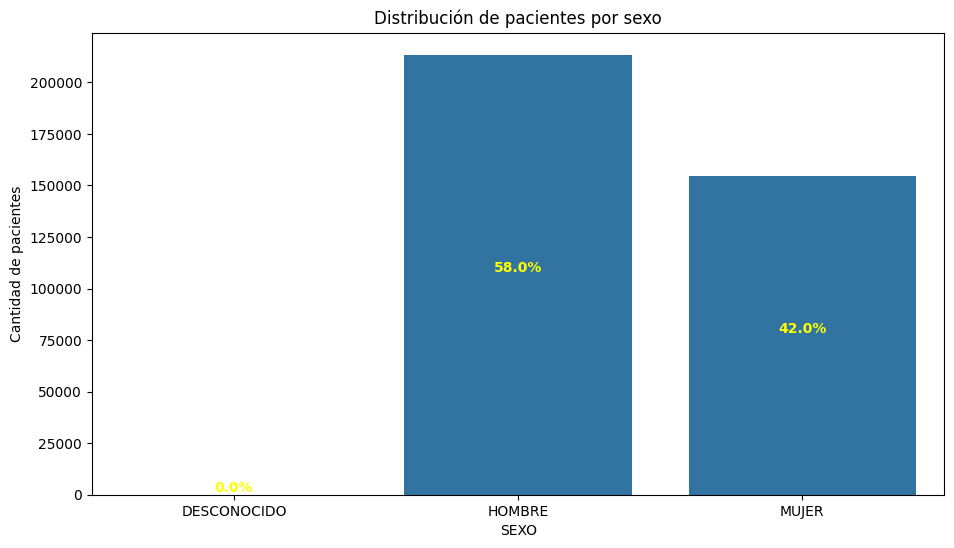

In [18]:
plt.figure(figsize=(11, 6))
ax = sns.countplot(data=grd, x='SEXO')
plt.title('Distribución de pacientes por sexo')
plt.ylabel('Cantidad de pacientes')
plt.xticks(rotation=0)

# Añadir porcentaje en las barras
total = len(grd)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() /2
    ax.annotate(percentage, (x, y), ha='center', va='bottom', color='yellow', weight='bold')

plt.show()

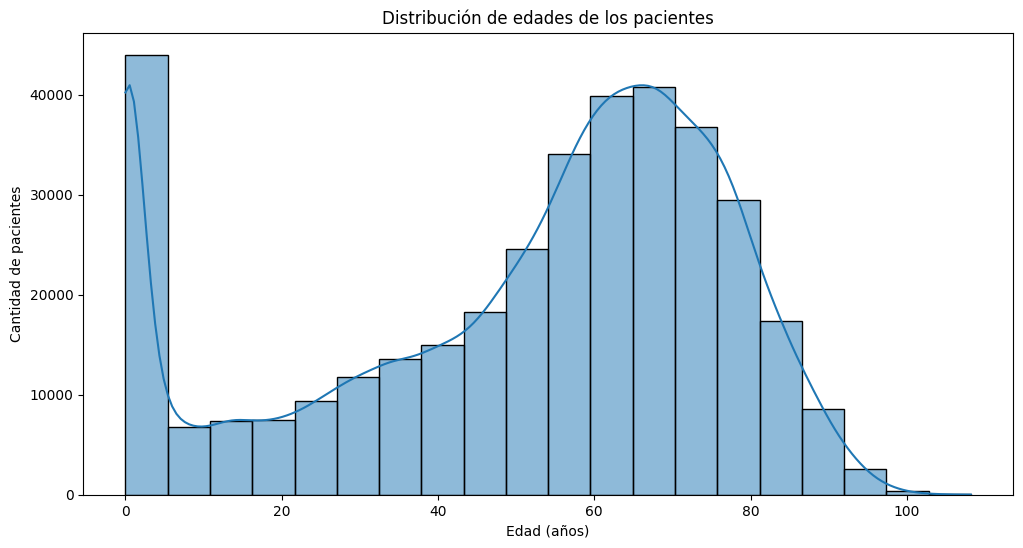

In [5]:
plt.figure(figsize=(12, 6))
# Filter data and convert EDAD to float to ensure compatibility with KDE
# edad_data = grdtest.dropna(subset=['EDAD'])['EDAD'].astype(float)
sns.histplot(grd['EDAD'], bins=20, kde=True)
plt.title('Distribución de edades de los pacientes')
plt.xlabel('Edad (años)')
plt.ylabel('Cantidad de pacientes')
plt.show()

Se estudian variables clave, como la severidad de los pacientes y dias de estancia, para poder entender como se distribuyen en paciente de hospitalización compleja.

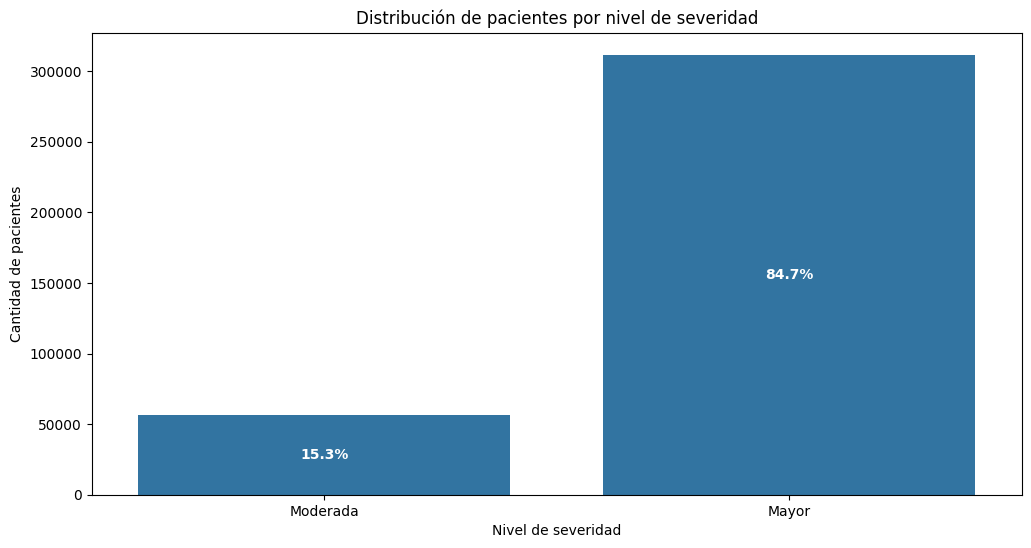

In [6]:
grd['IR_29301_SEVERIDAD'] = grd.IR_29301_SEVERIDAD.astype('string').astype('category')
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=grd, x='IR_29301_SEVERIDAD')
plt.title('Distribución de pacientes por nivel de severidad')
plt.xlabel('Nivel de severidad')
plt.ylabel('Cantidad de pacientes')
plt.xticks(ticks=[0, 1], labels=['Moderada', 'Mayor'])

# Añadir porcentaje en las barras
total = len(grd)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() / 2
    ax.annotate(percentage, (x, y), ha='center', va='center', color='white', weight='bold')

plt.show()

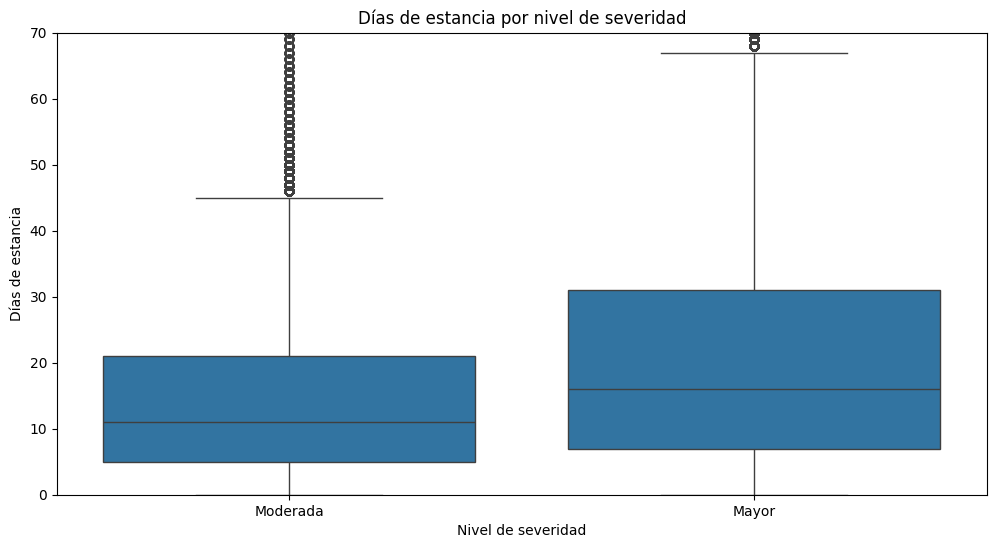

In [7]:
# Relación entre severidad y días de estancia
plt.figure(figsize=(12, 6))
sns.boxplot(data=grd, x='IR_29301_SEVERIDAD', y='DIAS_ESTANCIA')
plt.title('Días de estancia por nivel de severidad')
plt.xlabel('Nivel de severidad')
plt.ylabel('Días de estancia')
plt.xticks(ticks=[0, 1], labels=['Moderada', 'Mayor'])
plt.ylim(0, 70)  # Limitamos el eje Y para mejor visualización
plt.show()

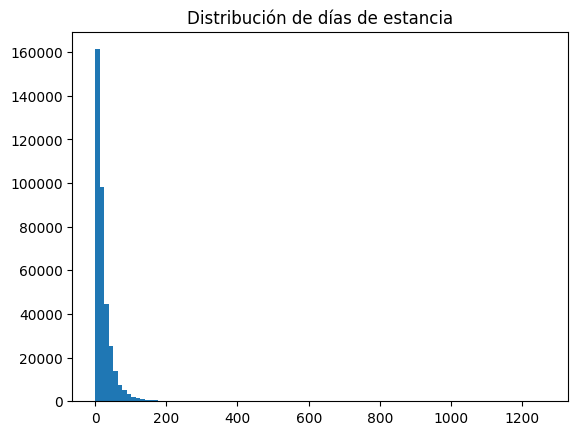

In [8]:
plt.hist(grd['DIAS_ESTANCIA'], bins=100)
plt.title('Distribución de días de estancia')
plt.show()

In [9]:
grd[grd['DIAS_ESTANCIA'] >= 400]['DIAS_ESTANCIA'].value_counts()

DIAS_ESTANCIA
407    5
419    4
489    4
458    3
400    3
      ..
484    1
579    1
503    1
630    1
456    1
Name: count, Length: 131, dtype: int64

Obtenemos ahora datos sobre la cantidad de pacientes y diagnosticos segun Servicio de Salud.

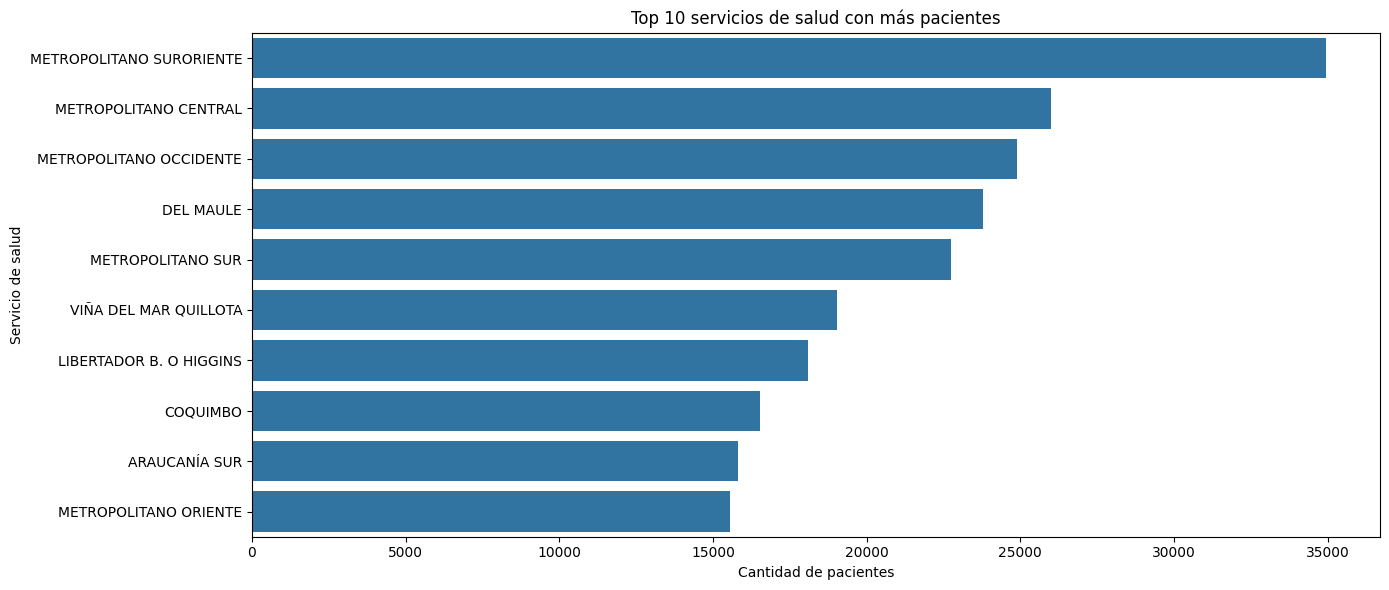

In [10]:
# Top 10 servicios de salud con más pacientes
plt.figure(figsize=(14, 6))
top_10_servicios = grd['SERVICIO_SALUD'].value_counts().head(10)
top_10_servicios.index = top_10_servicios.index.astype('string')
sns.barplot(top_10_servicios, orient='h')
plt.title('Top 10 servicios de salud con más pacientes')
plt.ylabel('Servicio de salud')
plt.xlabel('Cantidad de pacientes')
plt.tight_layout()
plt.show()

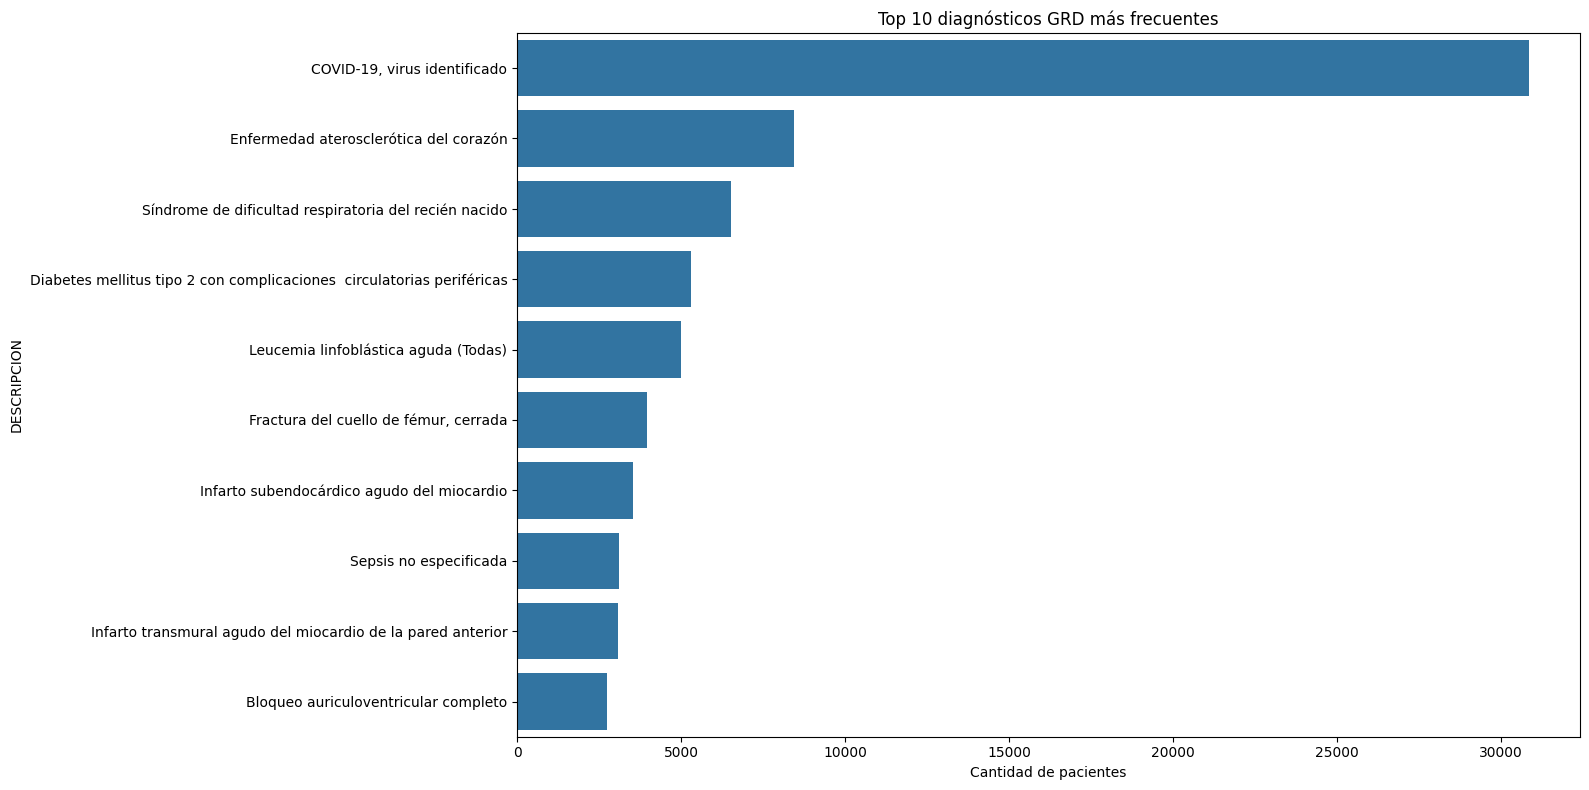

In [23]:
# Top 10 diagnósticos más frecuentes
plt.figure(figsize=(16, 8))
top_10_grd = grd['DIAGNOSTICO1'].value_counts().head(10)
top_10_diag = grd['DESCRIPCION'].value_counts().head(10)
sns.barplot(x=top_10_grd.values, y=top_10_diag.index)
plt.title('Top 10 diagnósticos GRD más frecuentes')
plt.xlabel('Cantidad de pacientes')
plt.tight_layout()
plt.show()

Se combinan variables anteriores para ver con más detalle relaciones entre severidad, edad, sexo, etc. 

<Figure size 3000x1000 with 0 Axes>

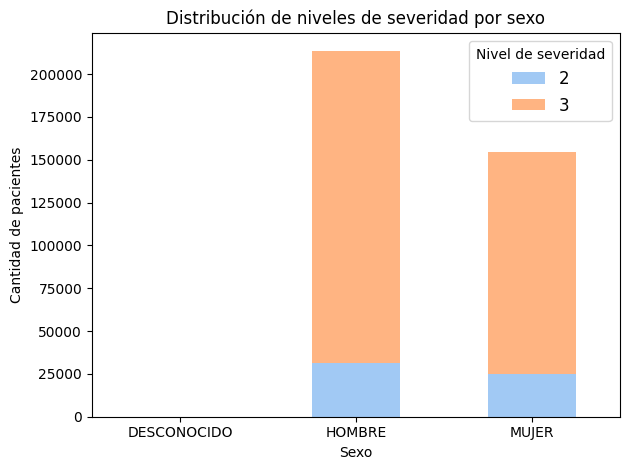

In [12]:
plt.figure(figsize=(30, 10))
crosstab = pd.crosstab(grd['SEXO'], grd['IR_29301_SEVERIDAD'])
crosstab.plot(kind='bar', stacked=True, color=sns.color_palette("pastel"))
plt.title('Distribución de niveles de severidad por sexo')
plt.xlabel('Sexo')
plt.ylabel('Cantidad de pacientes')
plt.legend(title='Nivel de severidad', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


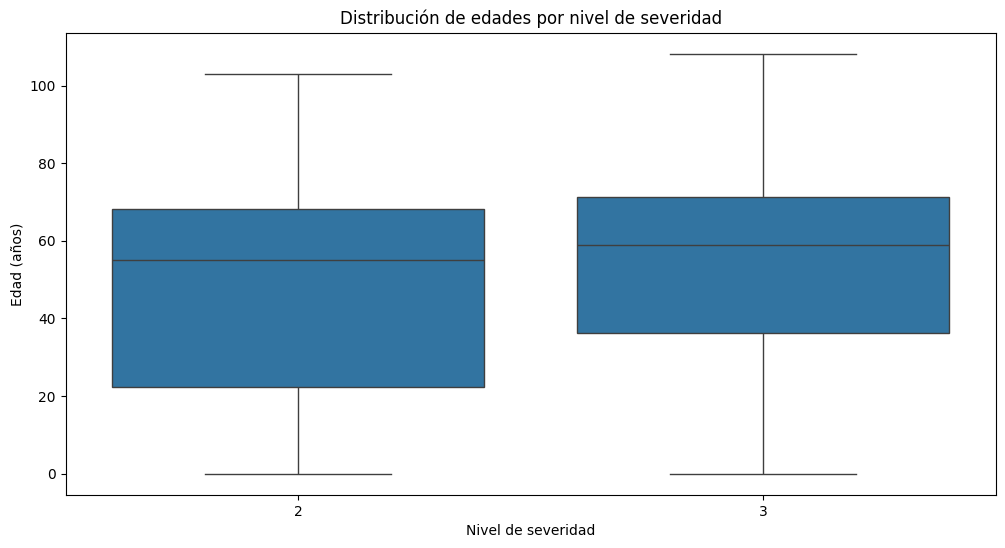

In [13]:
# Relación entre edad y severidad
plot_data = grd.dropna(subset=['IR_29301_SEVERIDAD', 'EDAD']).copy()
plot_data['IR_29301_SEVERIDAD'] = plot_data['IR_29301_SEVERIDAD'].astype('category')
plot_data['EDAD'] = plot_data['EDAD'].astype(float)

plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_data, x='IR_29301_SEVERIDAD', y='EDAD')
plt.title('Distribución de edades por nivel de severidad')
plt.xlabel('Nivel de severidad')
plt.ylabel('Edad (años)')
plt.show()

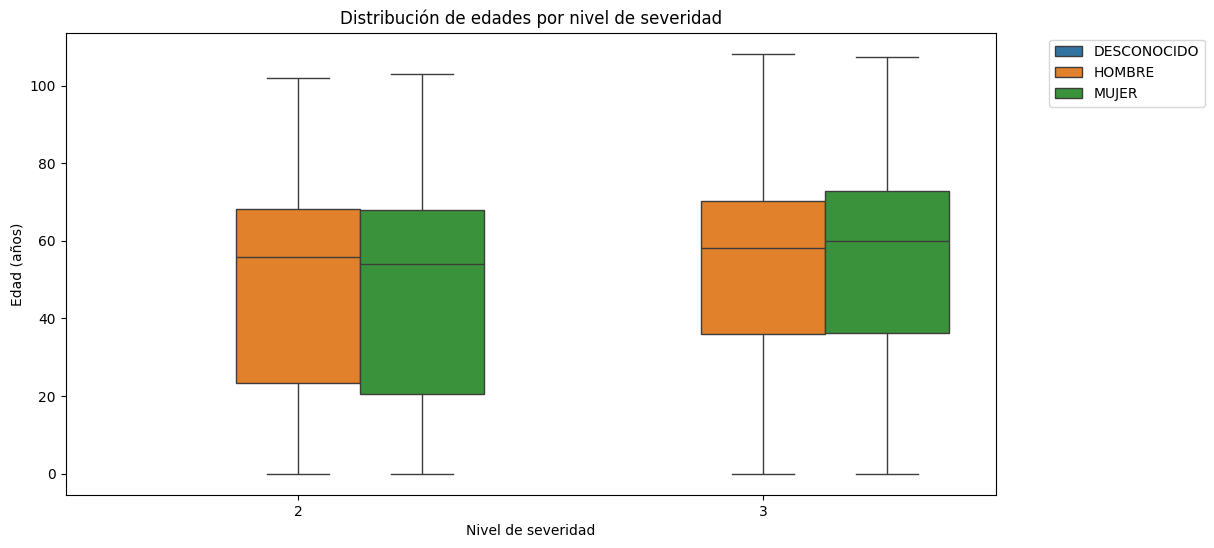

In [14]:
plt.figure(figsize=(12, 6))
data = grd[grd['SEXO'].notna() & (grd['SEXO'] != 'DESCONOCIDO')].dropna(subset=['EDAD', 'IR_29301_SEVERIDAD'])
sns.boxplot(data=data, x='IR_29301_SEVERIDAD', y='EDAD', hue='SEXO')
plt.title('Distribución de edades por nivel de severidad')
plt.xlabel('Nivel de severidad')
plt.ylabel('Edad (años)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Mueve la leyenda fuera del área del gráfico
plt.show()

Se comparan los top 5 hospitales según su peso promedio de GRD, que indica los costos en relación a una hospitalización promedio.

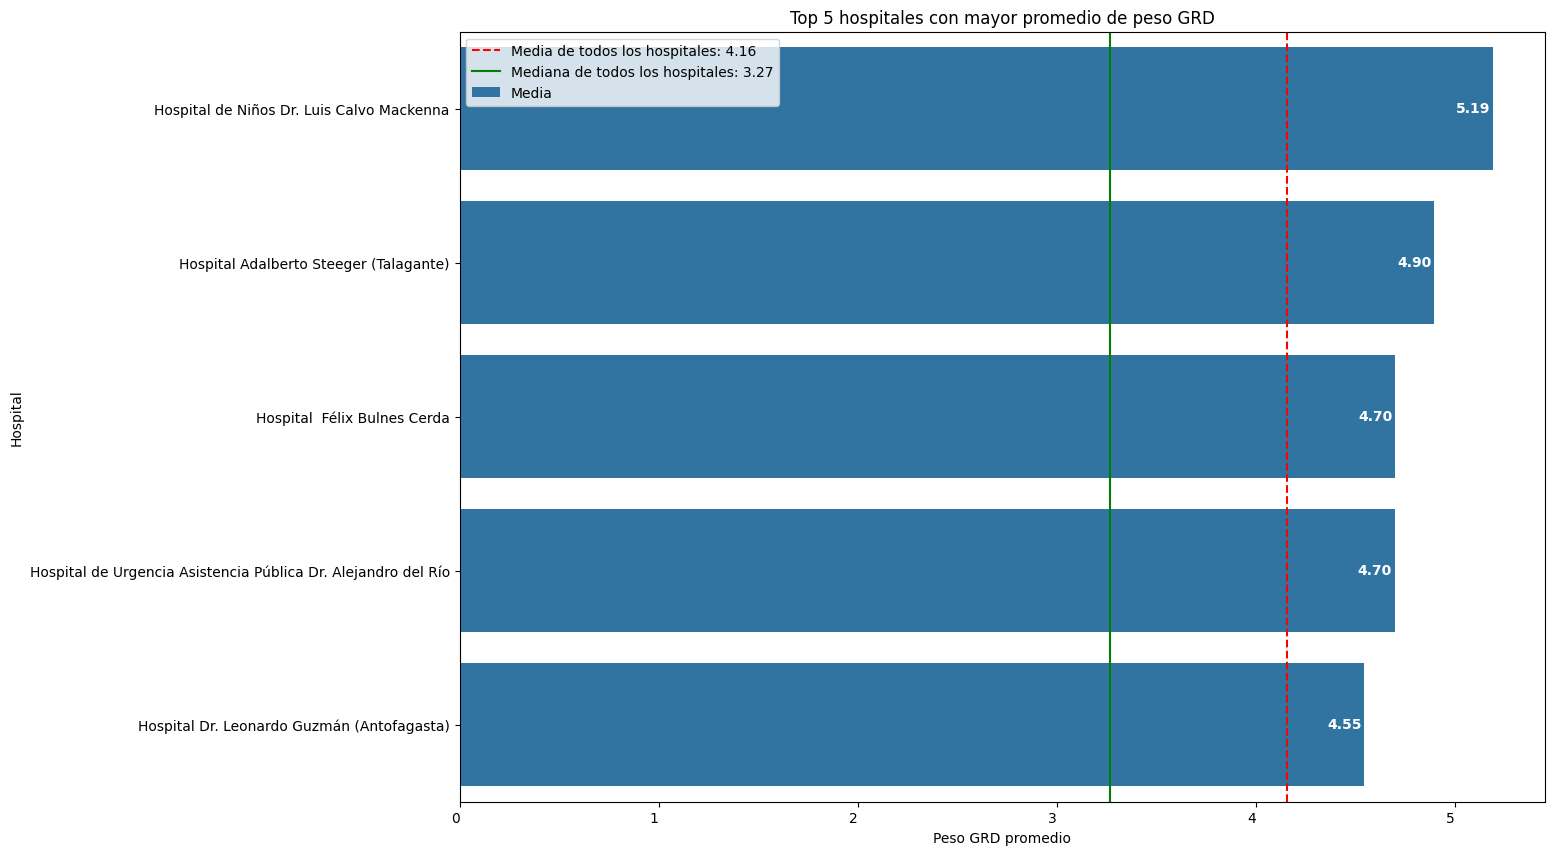

In [15]:
# Top 5 hospitales con mayor promedio de peso GRD (mayor complejidad)
# df_hospitales = pd.read_csv("datos/Hospitales.csv", header=None, names=['COD_HOSPITAL', 'NOMBRE_HOSPITAL'], sep="|")
hospital_peso = grd.groupby('ESTABLECIMIENTO')['IR_29301_PESO'].agg(['mean', 'median', 'count'])
hospital_peso = hospital_peso[hospital_peso['count'] > 100]  # Filtramos hospitales con pocos casos
hospital_peso = hospital_peso.sort_values('mean', ascending=False).head(5)

# Calculamos la media y mediana de todos los hospitales
mean_all = grd['IR_29301_PESO'].mean()
median_all = grd['IR_29301_PESO'].median()

plt.figure(figsize=(14, 10))
ax = sns.barplot(y=hospital_peso.index, x=hospital_peso['mean'], orient='h', label='Media')
plt.title('Top 5 hospitales con mayor promedio de peso GRD')
plt.ylabel('Hospital')
plt.xlabel('Peso GRD promedio')
plt.xticks(rotation=0, ha='right')

# Añadimos líneas verticales para la media y mediana de todos los hospitales
plt.axvline(mean_all, color='r', linestyle='--', label=f'Media de todos los hospitales: {mean_all:.2f}')
plt.axvline(median_all, color='g', linestyle='-', label=f'Mediana de todos los hospitales: {median_all:.2f}')

# Añadimos el promedio dentro de la barra en color blanco
for p in ax.patches:
    width = p.get_width()
    plt.text(width - 0.1, p.get_y() + p.get_height() / 2, f'{width:.2f}', ha='center', va='center', color='white', weight='bold')

plt.legend()
plt.show()


A continuación, se hace establecen las comunas donde sus habitantes se atienden afuera de ellas, estableciendolo cuando la comuna del registro del paciente sea distinta a la comuna del establecimiento de atención. 

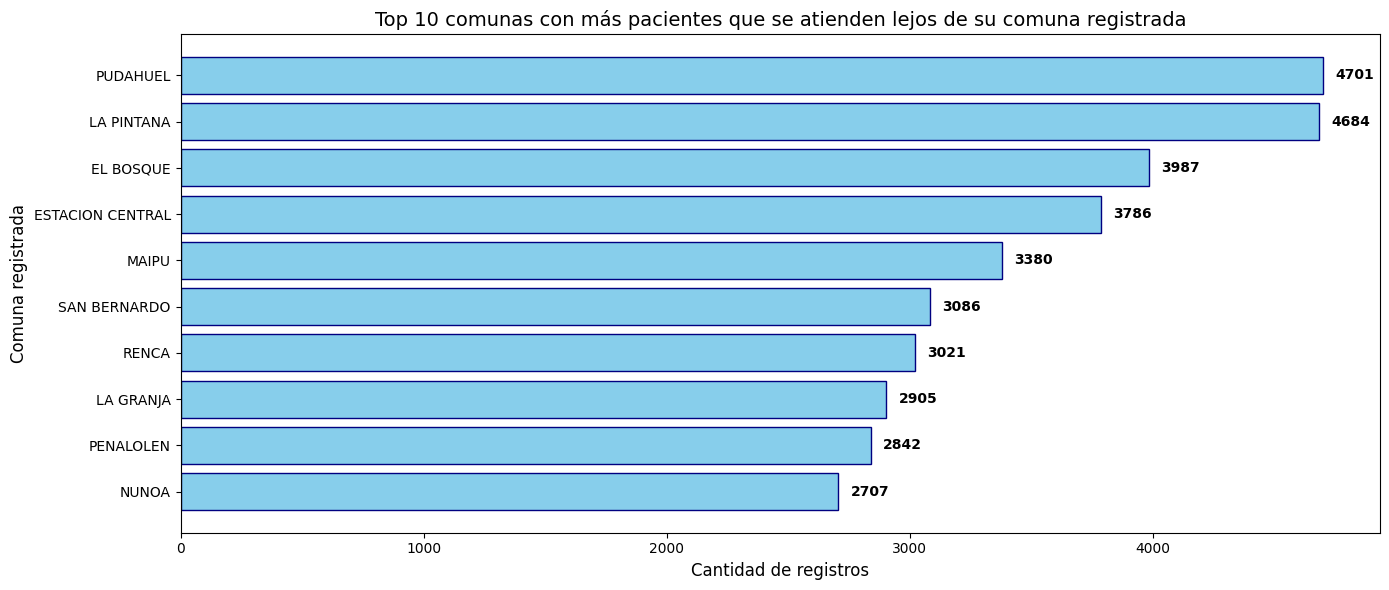

In [26]:
lejos = grd[grd['COMUNA_REGISTRADA'] != grd['COMUNA_ESTAB']]
#display(lejos.groupby('COMUNA_REGISTRADA')['CIP_ENCRIPTADO'].count().sort_values(ascending=False), )
top10lejos = lejos.groupby('COMUNA_REGISTRADA', observed=True)['CIP_ENCRIPTADO'].count().sort_values(ascending=True).tail(10)

top3lejos = lejos.groupby('COMUNA_REGISTRADA', observed=True)['CIP_ENCRIPTADO'].count().sort_values(ascending=False).head(3)


plt.figure(figsize=(14, 6))

# Usamos barh para barras horizontales
plt.barh(top10lejos.index, top10lejos.values, color='skyblue', edgecolor='navy')

# 3. Personalización
plt.title('Top 10 comunas con más pacientes que se atienden lejos de su comuna registrada', fontsize=14)
plt.xlabel('Cantidad de registros', fontsize=12)
plt.ylabel('Comuna registrada', fontsize=12)

# Opcional: Agregar el número exacto al final de cada barra para mayor claridad
for i, v in enumerate(top10lejos.values):
    plt.text(v + 50, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [32]:
#comparar cantidad de pacientes que se atienden cerca vs lejos de su comuna registrada de las comunas que estan en top10lejos
top10lejos2 = lejos.groupby('COMUNA_REGISTRADA', observed=True)['CIP_ENCRIPTADO'].count().sort_values(ascending=False).head(10)
for i in top10lejos2.index:
    cerca_count = grd[(grd['COMUNA_REGISTRADA'] == i) & (grd['COMUNA_ESTAB'] == i)]['CIP_ENCRIPTADO'].count()
    lejos_count = lejos[(lejos['COMUNA_REGISTRADA'] == i) & (lejos['COMUNA_ESTAB'] != i)]['CIP_ENCRIPTADO'].count()
    print(f"Comuna: {i} - Cerca: {cerca_count} pacientes, Lejos: {lejos_count} pacientes, porcentajes: Cerca: {cerca_count / (cerca_count + lejos_count) * 100:.1f}%, Lejos: {lejos_count / (cerca_count + lejos_count) * 100:.1f}%")

#total de hospitales en las comunas donde se atienden lejos
print("\nHospitales en las comunas donde se atienden lejos:")
for i in top10lejos2.index:
    #numero total de hospitales en la comuna registrada
    hospitales = grd.loc[grd['COMUNA_ESTAB'] == i, 'COD_ESTABLECIMIENTO'].nunique()
    print(f"Comuna: {i} - Hospitales: {hospitales}")


#donde se atienden los que no se atienden en su comuna registrada
print("\nComunas donde se atienden los pacientes que no se atienden en su comuna registrada:")
for i in top10lejos2.index:
    comunas_atencion = lejos.loc[lejos['COMUNA_REGISTRADA'] == i, 'COMUNA_ESTAB'].value_counts()
    print(f"\nComuna registrada: {i}")
    #revisamos cuantos hospitales hay en las comunas donde se atienden la mayoria de los pacientes que no se atienden en su comuna registrada
    #numero de hospitales en las primeras 3 comunas de atencións
    hospitales_atencion = grd.loc[grd['COMUNA_ESTAB'].isin(comunas_atencion.head(3).index), 'COD_ESTABLECIMIENTO'].nunique()
    print(f"Comunas de atención para pacientes de la comuna {i}:")
    print(comunas_atencion)
    print(f"{comunas_atencion.sum()} pacientes de la comuna {i} se atienden lejos de su comuna registrada")
    print(f"Hospitales en las comunas de atención: {comunas_atencion.head(3).index.tolist()}, {hospitales_atencion}")

Comuna: PUDAHUEL - Cerca: 0 pacientes, Lejos: 4701 pacientes, porcentajes: Cerca: 0.0%, Lejos: 100.0%
Comuna: LA PINTANA - Cerca: 0 pacientes, Lejos: 4684 pacientes, porcentajes: Cerca: 0.0%, Lejos: 100.0%
Comuna: EL BOSQUE - Cerca: 0 pacientes, Lejos: 3987 pacientes, porcentajes: Cerca: 0.0%, Lejos: 100.0%
Comuna: ESTACION CENTRAL - Cerca: 0 pacientes, Lejos: 3786 pacientes, porcentajes: Cerca: 0.0%, Lejos: 100.0%
Comuna: MAIPU - Cerca: 6923 pacientes, Lejos: 3380 pacientes, porcentajes: Cerca: 67.2%, Lejos: 32.8%
Comuna: SAN BERNARDO - Cerca: 2410 pacientes, Lejos: 3086 pacientes, porcentajes: Cerca: 43.9%, Lejos: 56.1%
Comuna: RENCA - Cerca: 0 pacientes, Lejos: 3021 pacientes, porcentajes: Cerca: 0.0%, Lejos: 100.0%
Comuna: LA GRANJA - Cerca: 0 pacientes, Lejos: 2905 pacientes, porcentajes: Cerca: 0.0%, Lejos: 100.0%
Comuna: PENALOLEN - Cerca: 2448 pacientes, Lejos: 2842 pacientes, porcentajes: Cerca: 46.3%, Lejos: 53.7%
Comuna: NUNOA - Cerca: 0 pacientes, Lejos: 2707 pacientes, por

In [40]:
# top 3 diagnosticos de top 3 comunas lejos por todos los años (2019-2024)
for i in grd['YEAR'].unique():
    top10lejos2 = lejos.groupby('COMUNA_REGISTRADA', observed=True)['CIP_ENCRIPTADO'].count().sort_values(ascending=False).head(3)
    print(f"\nAño: {i}")
    for comuna in top10lejos2.index:
        a = grd[(grd['COMUNA_REGISTRADA'] == comuna) & (grd['YEAR'] == i)][['DIAGNOSTICO1','DESCRIPCION']].value_counts().head(3)
        #print(f"\nComuna: {comuna}")
        #juntar diagnosticos de las 3 comunas en un solo dataframe para cada año
    df_diagnosticos = pd.concat([grd[(grd['COMUNA_REGISTRADA'] == comuna) & (grd['YEAR'] == i)][['DIAGNOSTICO1','DESCRIPCION']].value_counts().head(3) for comuna in top10lejos2.index], keys=top10lejos2.index)
    display(pd.DataFrame(df_diagnosticos.sort_values(ascending=False)))

        #grafico de barras para cada comuna y año
    """plt.figure(figsize=(10, 5))
    sns.barplot(x=a.values, y=a.index, orient='h', color='lightblue', edgecolor='navy')
    plt.title(f'Top 3 diagnósticos en {comuna} en el año {i}', fontsize=14)
    plt.xlabel('Cantidad de pacientes', fontsize=12)
    plt.ylabel('Diagnóstico', fontsize=12)
    for j, v in enumerate(a.values):
        plt.text(v + 5, j, str(v), va='center', fontweight='bold')
    plt.tight_layout()"""


Año: 2019


count
COMUNA_REGISTRADA DIAGNOSTICO1 DESCRIPCION                                              
EL BOSQUE         A41.8        Otras septicemias especificadas                        25
PUDAHUEL          P22.0        Síndrome de dificultad respiratoria del recién ...     21
                  J96.0        Insuficiencia respiratoria aguda                       18
                  I21.4        Infarto subendocárdico agudo del miocardio             16
LA PINTANA        A41.9        Sepsis no especificada                                 14
EL BOSQUE         A41.9        Sepsis no especificada                                 14
                  J18.9        Neumonía, no especificada                              14
LA PINTANA        P22.0        Síndrome de dificultad respiratoria del recién ...     12
                  I44.2        Bloqueo auriculoventricular completo                   11


Año: 2020


count
COMUNA_REGISTRADA DIAGNOSTICO1 DESCRIPCION                                              
LA PINTANA        U07.1        COVID-19, virus identificado                          173
PUDAHUEL          U07.1        COVID-19, virus identificado                          143
EL BOSQUE         U07.1        COVID-19, virus identificado                          134
PUDAHUEL          P22.0        Síndrome de dificultad respiratoria del recién ...     20
                  C91.0        Leucemia linfoblástica aguda (Todas)                   18
LA PINTANA        P22.0        Síndrome de dificultad respiratoria del recién ...     15
EL BOSQUE         A41.8        Otras septicemias especificadas                        12
LA PINTANA        S72.00       Fractura del cuello de fémur, cerrada                  11
EL BOSQUE         E11.5        Diabetes mellitus tipo 2 con complicaciones  ci...     11


Año: 2021


...

count
COMUNA_REGISTRADA DIAGNOSTICO1 DESCRIPCION                                              
PUDAHUEL          U07.1        COVID-19, virus identificado                           27
EL BOSQUE         U07.1        COVID-19, virus identificado                           20
LA PINTANA        U07.1        COVID-19, virus identificado                           19
                  C91.0        Leucemia linfoblástica aguda (Todas)                   18
PUDAHUEL          P22.0        Síndrome de dificultad respiratoria del recién ...     16
EL BOSQUE         P22.0        Síndrome de dificultad respiratoria del recién ...     16
LA PINTANA        E11.5        Diabetes mellitus tipo 2 con complicaciones  ci...     16
EL BOSQUE         E11.5        Diabetes mellitus tipo 2 con complicaciones  ci...     14
PUDAHUEL          C91.0        Leucemia linfoblástica aguda (Todas)                   12


Año: 2023


count
COMUNA_REGISTRADA DIAGNOSTICO1 DESCRIPCION                                              
LA PINTANA        C91.0        Leucemia linfoblástica aguda (Todas)                   24
PUDAHUEL          I21.0        Infarto transmural agudo del miocardio de la pa...     22
LA PINTANA        S72.10       Fractura pertrocanteriana, cerrada                     21
                  E11.5        Diabetes mellitus tipo 2 con complicaciones  ci...     19
PUDAHUEL          P22.0        Síndrome de dificultad respiratoria del recién ...     16
EL BOSQUE         E11.5        Diabetes mellitus tipo 2 con complicaciones  ci...     16
PUDAHUEL          I21.1        Infarto transmural agudo del miocardio de la pa...     15
EL BOSQUE         J96.09       Insuficiencia respiratoria aguda, Tipo no espec...     14
                  J12.1        Neumonía debida a virus sincitial respiratorio         13


Año: 2024


count
COMUNA_REGISTRADA DIAGNOSTICO1 DESCRIPCION                                              
PUDAHUEL          I21.4        Infarto subendocárdico agudo del miocardio             29
                  S72.10       Fractura pertrocanteriana, cerrada                     21
LA PINTANA        C91.0        Leucemia linfoblástica aguda (Todas)                   20
EL BOSQUE         A41.8        Otras septicemias especificadas                        20
LA PINTANA        I77.1        Estrechez arterial                                     18
                  E11.5        Diabetes mellitus tipo 2 con complicaciones  ci...     17
PUDAHUEL          E11.5        Diabetes mellitus tipo 2 con complicaciones  ci...     15
EL BOSQUE         J18.9        Neumonía, no especificada                              14
                  J96.09       Insuficiencia respiratoria aguda, Tipo no espec...     13

In [36]:
for comuna in top10lejos.index:
    a = pd.DataFrame(grd[grd['COMUNA_REGISTRADA'] == comuna][['DIAGNOSTICO1','DESCRIPCION']].value_counts().head(3))
    print(f"\nComuna: {comuna}")
    display(a)


Comuna: NUNOA


,,count
DIAGNOSTICO1,DESCRIPCION,
U07.1,"COVID-19, virus identificado",152
Z45.0,Asistencia y ajuste de marcapaso cardíaco,125
I25.1,Enfermedad aterosclerótica del corazón,52



Comuna: PENALOLEN


,,count
DIAGNOSTICO1,DESCRIPCION,
U07.1,"COVID-19, virus identificado",491
P22.0,Síndrome de dificultad respiratoria del recién nacido,91
Z45.0,Asistencia y ajuste de marcapaso cardíaco,90



Comuna: LA GRANJA


...

,,count
DIAGNOSTICO1,DESCRIPCION,
U07.1,"COVID-19, virus identificado",363
A41.8,Otras septicemias especificadas,77
E11.5,Diabetes mellitus tipo 2 con complicaciones circulatorias periféricas,72



Comuna: LA PINTANA


,,count
DIAGNOSTICO1,DESCRIPCION,
U07.1,"COVID-19, virus identificado",417
P22.0,Síndrome de dificultad respiratoria del recién nacido,82
C91.0,Leucemia linfoblástica aguda (Todas),67



Comuna: PUDAHUEL


,,count
DIAGNOSTICO1,DESCRIPCION,
U07.1,"COVID-19, virus identificado",459
P22.0,Síndrome de dificultad respiratoria del recién nacido,100
I21.4,Infarto subendocárdico agudo del miocardio,87


## Estimacion estadistica (estimadores puntuales)

En esta seccion seguimos la misma linea del EDA para obtener estimadores puntuales de parametros de interes:

- Promedios (media muestral)
- Proporciones (proporcion muestral)

Primero se calcula un resumen global del dataset cargado en `grd`.

In [18]:
import pandas as pd

if 'grd' not in globals():
    grd = pd.read_parquet('grd_procesado.parquet')

# Parametros para promedio
vars_promedio = ['EDAD', 'DIAS_ESTANCIA', 'IR_29301_PESO']

# Parametros para proporcion 
def evento_severidad_mayor(df):
    return df['IR_29301_SEVERIDAD'].astype('string').eq('3')

def evento_sexo_femenino(df):
    return df['SEXO'].astype('string').str.upper().eq('F')

proporciones = {
    'Proporcion severidad mayor (IR_29301_SEVERIDAD = 3)': evento_severidad_mayor,
    'Proporcion sexo femenino (SEXO = F)': evento_sexo_femenino,
}

filas = []

# 1) Estimadores puntuales de medias
for var in vars_promedio:
    serie = pd.to_numeric(grd[var], errors='coerce').dropna()
    n = int(serie.shape[0])
    if n > 0:
        filas.append({
            'Parametro': f'Media poblacional de {var}',
            'Tipo_estimador': 'Media muestral',
            'Estimador_puntual': float(serie.mean()),
            'N_utilizado': n
        })

# 2) Estimadores puntuales de proporciones
for nombre_parametro, regla in proporciones.items():
    indicador = regla(grd)
    indicador = indicador.where(indicador.notna()).dropna()
    n = int(indicador.shape[0])
    if n > 0:
        filas.append({
            'Parametro': nombre_parametro,
            'Tipo_estimador': 'Proporcion muestral',
            'Estimador_puntual': float(indicador.mean()),
            'N_utilizado': n
        })

# Tabla resumen final
tabla_estimadores = pd.DataFrame(filas)
tabla_estimadores['Estimador_puntual'] = tabla_estimadores['Estimador_puntual'].round(4)

print('Tabla de resumen de estimadores puntuales:')
display(tabla_estimadores)


Tabla de resumen de estimadores puntuales:


,Parametro,Tipo_estimador,Estimador_puntual,N_utilizado
0,Media poblacional de EDAD,Media muestral,50.9870,367895
1,Media poblacional de DIAS_ESTANCIA,Media muestral,23.1609,367895
2,Media poblacional de IR_29301_PESO,Media muestral,4.1581,367895
3,Proporcion severidad mayor (IR_29301_SEVERIDAD...,Proporcion muestral,0.8472,367895
4,Proporcion sexo femenino (SEXO = F),Proporcion muestral,0.0000,367895


## Ajuste de proporciones y analisis por año

Para mantener consistencia con el EDA, primero identificamos como esta codificada la variable `SEXO` y definimos una regla para estimar la proporcion femenina.

Luego calculamos estimadores puntuales por año y agregamos intervalos de confianza al 95% para medias y proporciones.

In [19]:
import numpy as np
import pandas as pd

if 'grd' not in globals():
    grd = pd.read_parquet('grd_procesado.parquet')

# Inspeccion rapida de codigos de sexo para definir regla coherente
sexo_vals = grd['SEXO'].astype('string').str.strip().str.upper()
print('Valores unicos observados en SEXO:')
print(sorted(sexo_vals.dropna().unique().tolist()))

# Regla: considera codigos frecuentes de femenino en fuentes administrativas
def evento_sexo_femenino_robusto(df):
    vals = df['SEXO'].astype('string').str.strip().str.upper()
    codigos_femenino = {'F', 'FEMENINO', 'MUJER', '2'}
    codigos_validos = codigos_femenino.union({'M', 'MASCULINO', 'HOMBRE', '1'})

    # Se consideran como validos solo codigos hombre/mujer esperados
    es_valido = vals.isin(codigos_validos)
    indicador = vals.isin(codigos_femenino)
    return indicador.where(es_valido)

# Recalculo de la tabla global con regla corregida para sexo
vars_promedio = ['EDAD', 'DIAS_ESTANCIA', 'IR_29301_PESO']
proporciones = {
    'Proporcion severidad mayor (IR_29301_SEVERIDAD = 3)': lambda d: d['IR_29301_SEVERIDAD'].astype('string').eq('3'),
    'Proporcion sexo femenino (regla robusta)': evento_sexo_femenino_robusto,
}

filas = []
for var in vars_promedio:
    serie = pd.to_numeric(grd[var], errors='coerce').dropna()
    n = int(serie.shape[0])
    if n > 0:
        filas.append({
            'Ambito': 'Global',
            'Parametro': f'Media poblacional de {var}',
            'Tipo_estimador': 'Media muestral',
            'Estimador_puntual': float(serie.mean()),
            'N_utilizado': n
        })

for nombre_parametro, regla in proporciones.items():
    indicador = regla(grd)
    indicador = indicador.dropna()
    n = int(indicador.shape[0])
    if n > 0:
        filas.append({
            'Ambito': 'Global',
            'Parametro': nombre_parametro,
            'Tipo_estimador': 'Proporcion muestral',
            'Estimador_puntual': float(indicador.mean()),
            'N_utilizado': n
        })

tabla_estimadores_global = pd.DataFrame(filas)
tabla_estimadores_global['Estimador_puntual'] = tabla_estimadores_global['Estimador_puntual'].round(4)

print('Tabla global actualizada:')
display(tabla_estimadores_global)

Valores unicos observados en SEXO:
['DESCONOCIDO', 'HOMBRE', 'MUJER']
Tabla global actualizada:


,Ambito,Parametro,Tipo_estimador,Estimador_puntual,N_utilizado
0,Global,Media poblacional de EDAD,Media muestral,50.9870,367895
1,Global,Media poblacional de DIAS_ESTANCIA,Media muestral,23.1609,367895
2,Global,Media poblacional de IR_29301_PESO,Media muestral,4.1581,367895
3,Global,Proporcion severidad mayor (IR_29301_SEVERIDAD...,Proporcion muestral,0.8472,367895
4,Global,Proporcion sexo femenino (regla robusta),Proporcion muestral,0.4198,367853


In [20]:
# Estimadores puntuales por año
if 'Year' not in grd.columns:
    grd['Year'] = pd.to_datetime(grd['FECHA_INGRESO'], errors='coerce').dt.year

filas_year = []
for year, g in grd.dropna(subset=['Year']).groupby('Year'):
    # Medias
    for var in ['EDAD', 'DIAS_ESTANCIA', 'IR_29301_PESO']:
        serie = pd.to_numeric(g[var], errors='coerce').dropna()
        n = int(serie.shape[0])
        if n > 0:
            filas_year.append({
                'Ambito': f'Year={int(year)}',
                'Year': int(year),
                'Parametro': f'Media poblacional de {var}',
                'Tipo_estimador': 'Media muestral',
                'Estimador_puntual': float(serie.mean()),
                'N_utilizado': n
            })

    # Proporciones
    ind_sev = g['IR_29301_SEVERIDAD'].astype('string').eq('3').dropna()
    if ind_sev.shape[0] > 0:
        filas_year.append({
            'Ambito': f'Year={int(year)}',
            'Year': int(year),
            'Parametro': 'Proporcion severidad mayor (IR_29301_SEVERIDAD = 3)',
            'Tipo_estimador': 'Proporcion muestral',
            'Estimador_puntual': float(ind_sev.mean()),
            'N_utilizado': int(ind_sev.shape[0])
        })

    ind_fem = evento_sexo_femenino_robusto(g).dropna()
    if ind_fem.shape[0] > 0:
        filas_year.append({
            'Ambito': f'Year={int(year)}',
            'Year': int(year),
            'Parametro': 'Proporcion sexo femenino (regla)',
            'Tipo_estimador': 'Proporcion muestral',
            'Estimador_puntual': float(ind_fem.mean()),
            'N_utilizado': int(ind_fem.shape[0])
        })

tabla_estimadores_year = pd.DataFrame(filas_year)
tabla_estimadores_year['Estimador_puntual'] = tabla_estimadores_year['Estimador_puntual'].round(4)

print('Tabla de estimadores puntuales por anio:')
display(tabla_estimadores_year.sort_values(['Year', 'Tipo_estimador', 'Parametro']).reset_index(drop=True))

Tabla de estimadores puntuales por anio:


,Ambito,Year,Parametro,Tipo_estimador,Estimador_puntual,N_utilizado
0,Year=2019,2019,Media poblacional de DIAS_ESTANCIA,Media muestral,24.0087,50135
1,Year=2019,2019,Media poblacional de EDAD,Media muestral,49.3876,50135
2,Year=2019,2019,Media poblacional de IR_29301_PESO,Media muestral,3.9352,50135
3,Year=2019,2019,Proporcion severidad mayor (IR_29301_SEVERIDAD...,Proporcion muestral,0.8129,50135
4,Year=2019,2019,Proporcion sexo femenino (regla),Proporcion muestral,0.4311,50129
5,Year=2020,2020,Media poblacional de DIAS_ESTANCIA,Media muestral,24.0649,54370
6,Year=2020,2020,Media poblacional de EDAD,Media muestral,51.0162,54370
7,Year=2020,2020,Media poblacional de IR_29301_PESO,Media muestral,4.3668,54370
8,Year=2020,2020,Proporcion severidad mayor (IR_29301_SEVERIDAD...,Proporcion muestral,0.8635,54370
9,Year=2020,2020,Proporcion sexo femenino (regla),Proporcion muestral,0.4013,54354


In [21]:
# Intervalos de confianza (95%) para estimadores globales y por año

Z_95 = 1.96

def agregar_ic95(tabla):
    out = tabla.copy()
    n = pd.to_numeric(out['N_utilizado'], errors='coerce')
    est = pd.to_numeric(out['Estimador_puntual'], errors='coerce')

    # Error estandar segun tipo de estimador
    es_media = out['Tipo_estimador'].eq('Media muestral')

    se = pd.Series(np.nan, index=out.index, dtype='float64')

    for i, row in out.iterrows():
        amb = row['Ambito']
        param = row['Parametro']

        if row['Tipo_estimador'] == 'Media muestral':
            if 'EDAD' in param:
                col = 'EDAD'
            elif 'DIAS_ESTANCIA' in param:
                col = 'DIAS_ESTANCIA'
            else:
                col = 'IR_29301_PESO'

            if amb == 'Global':
                s = pd.to_numeric(grd[col], errors='coerce').dropna()
            else:
                year = int(str(amb).replace('Year=', ''))
                s = pd.to_numeric(grd.loc[grd['Year'] == year, col], errors='coerce').dropna()

            if s.shape[0] > 1:
                se.iloc[i] = s.std(ddof=1) / np.sqrt(s.shape[0])

        else:
            if pd.notna(n.iloc[i]) and n.iloc[i] > 0 and pd.notna(est.iloc[i]):
                p = est.iloc[i]
                se.iloc[i] = np.sqrt((p * (1 - p)) / n.iloc[i])

    out['IC95_inf'] = (est - Z_95 * se).round(4)
    out['IC95_sup'] = (est + Z_95 * se).round(4)

    mask_prop = out['Tipo_estimador'].eq('Proporcion muestral')
    out.loc[mask_prop, 'IC95_inf'] = out.loc[mask_prop, 'IC95_inf'].clip(lower=0)
    out.loc[mask_prop, 'IC95_sup'] = out.loc[mask_prop, 'IC95_sup'].clip(upper=1)

    return out

tabla_global_ic95 = agregar_ic95(tabla_estimadores_global)
tabla_year_ic95 = agregar_ic95(tabla_estimadores_year)

tabla_final_estimadores = pd.concat([tabla_global_ic95, tabla_year_ic95], ignore_index=True)

print('Resumen final con estimadores puntuales e IC95%:')
display(tabla_final_estimadores)

Resumen final con estimadores puntuales e IC95%:


,Ambito,Parametro,Tipo_estimador,Estimador_puntual,N_utilizado,IC95_inf,IC95_sup,Year
0,Global,Media poblacional de EDAD,Media muestral,50.9870,367895,50.9022,51.0718,NaN
1,Global,Media poblacional de DIAS_ESTANCIA,Media muestral,23.1609,367895,23.0644,23.2574,NaN
2,Global,Media poblacional de IR_29301_PESO,Media muestral,4.1581,367895,4.1497,4.1665,NaN
3,Global,Proporcion severidad mayor (IR_29301_SEVERIDAD...,Proporcion muestral,0.8472,367895,0.8460,0.8484,NaN
4,Global,Proporcion sexo femenino (regla robusta),Proporcion muestral,0.4198,367853,0.4182,0.4214,NaN
5,Year=2019,Media poblacional de EDAD,Media muestral,49.3876,50135,49.1435,49.6317,2019.0
6,Year=2019,Media poblacional de DIAS_ESTANCIA,Media muestral,24.0087,50135,23.7050,24.3124,2019.0
7,Year=2019,Media poblacional de IR_29301_PESO,Media muestral,3.9352,50135,3.9138,3.9566,2019.0
8,Year=2019,Proporcion severidad mayor (IR_29301_SEVERIDAD...,Proporcion muestral,0.8129,50135,0.8095,0.8163,2019.0
9,Year=2019,Proporcion sexo femenino (regla),Proporcion muestral,0.4311,50129,0.4268,0.4354,2019.0


## Test de Hipótesis: desmintiendo nuestras creencias
Como grupo, siempre estuvimos enfocados en comunas que no tuvieran presencia de establecimientos de salud de alta complejidad. Pensabamos que esto tendría un efecto en los pacientes, lo que se vería reflejado en la proporción de fallecidos en comunas sin establecimientos, con una mayor mortalidad. Nuestro test de hipótesis es el siguiente:<br>
<br>
¿Hay una diferencia estadísticamente significativa entre mortalidad y presencia de hospital de alta complejidad en una comuna? <br>
<br>
Variables:
- p1: la proporción de mortalidad en pacientes de comunas que cuentan con hospital complejo <br>
- p2: la proporción de mortalidad en pacientes de comunas sin hospital de alta complejidad <br>
</ul>
H0: p1 = p2, no hay diferencias entre las proporciones de mortalidad en pacientes que vengan de comunas sin y con hospital complejo. <br>
<br>
H1: p1 ≠ p2, hay una diferencia significativa entre las proporciones de mortalidad entre los dos grupos. 

In [ ]:
# librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.proportion import proportions_ztest
df = pd.read_parquet('grd_procesado.parquet')

In [ ]:
# funciones que cumplen diferentes roles en proceso del test de hipótesis
def fmt_p(p):
    if p < 1e-16:
        return "< 1e-16"
    return f"{p:.4g}"
# muestra el resultado final, con un gráfico de barras marcado con los valores
def show_bar_proportions(series, title, ylabel="Proporción (%)", rotation=0):
    ax = (series * 100).plot(kind="bar", figsize=(7, 4))
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}%",
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=10)
    plt.tight_layout()
    plt.show()
# cálcula el coeficiente de la V de Crame, util para analizar resultados
def cramers_v(table):
    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    r, c = table.shape
    return np.sqrt(chi2 / (n * min(r - 1, c - 1)))
# incluye texto en el resultado de la V de Cramer
def interpret_cramers_v(v):
    # Regla orientativa sencilla para clase
    if v < 0.10:
        return "muy pequeño / débil"
    elif v < 0.30:
        return "pequeño a moderado"
    elif v < 0.50:
        return "moderado"
    else:
        return "grande"

Se realiza un conteo de los casos, según mortalidad y presencia de estab. de alta complejidad en la comuna.

In [ ]:
# tabla de contingencia de pandas, usando datos del GRD
tab1 = pd.crosstab(
    df["COMUNA_CON_ESTAB_AC"].map({0:"Sin Estab. A.C.",1:"Con Estab. A.C."}),
    df["FALLECIDO"])
# se le cambia nombre a los valores para ser faciles de interpretar
tab1.columns = ["No fallecido", "Fallecido"]
# se muestran resultados
print("Tabla de contingencia (conteos):")
display(tab1)
# para normalizar resultados, se calcula la proporción, respecto al total de casos,
# según presencia de establecimientos AC en comuna
tab1_prop = tab1.div(tab1.sum(axis=1), axis=0)
print("Tabla de contingencia (proporciones por fila):")
display((tab1_prop * 100).round(2))

Tabla de contingencia (conteos):


,No fallecido,Fallecido
COMUNA_CON_ESTAB_AC,,
Con Estab. A.C.,180576,38883
Sin Estab. A.C.,122599,25837


Tabla de contingencia (proporciones por fila):


,No fallecido,Fallecido
COMUNA_CON_ESTAB_AC,,
Con Estab. A.C.,82.28,17.72
Sin Estab. A.C.,82.59,17.41


In [ ]:
# Chi-cuadrado
chi2_1, p_1, dof_1, exp_1 = chi2_contingency(tab1)

# z de dos proporciones
counts = tab1["Fallecido"].values
nobs = tab1.sum(axis=1).values
z_1, pz_1 = proportions_ztest(counts, nobs)

# Diferencia absoluta de proporciones e IC95% (aprox. Wald, suficiente para este notebook)
comunas_sin = counts[0] / nobs[0]
comunas_con = counts[1] / nobs[1]
diff = comunas_sin - comunas_con
se_diff = np.sqrt(comunas_sin * (1 - comunas_sin) / nobs[0] + comunas_con * (1 - comunas_con) / nobs[1])
ci_low = diff - 1.96 * se_diff
ci_high = diff + 1.96 * se_diff

# Odds ratio con IC95%
a = tab1.loc["Sin Estab. A.C.", "Fallecido"]
b = tab1.loc["Sin Estab. A.C.", "No fallecido"]
c = tab1.loc["Con Estab. A.C.", "Fallecido"]
d = tab1.loc["Con Estab. A.C.", "No fallecido"]
odds_ratio = (a / b) / (c / d)
se_log_or = np.sqrt(1 / a + 1 / b + 1 / c + 1 / d)
or_low = np.exp(np.log(odds_ratio) - 1.96 * se_log_or)
or_high = np.exp(np.log(odds_ratio) + 1.96 * se_log_or)

print("Resultados principales")
print(f"- Proporción de fallecidos en comunas SIN establecimiento complejo: {comunas_sin*100:.2f}%")
print(f"- Proporción de fallecidos en comunas CON establecimiento complejo: {comunas_con*100:.2f}%")
print(f"- Diferencia absoluta: {diff*100:.2f} puntos porcentuales")
print(f"- IC95% de la diferencia: [{ci_low*100:.2f}, {ci_high*100:.2f}] pp")
print(f"- Chi-cuadrado = {chi2_1:,.2f}, gl = {dof_1}, p {fmt_p(p_1)}")
print(f"- z de dos proporciones = {z_1:,.2f}, p {fmt_p(pz_1)}")
print(f"- Odds ratio = {odds_ratio:.3f} (IC95%: {or_low:.3f} a {or_high:.3f})")
print(f"- V de Cramér = {cramers_v(tab1):.3f} -> efecto {interpret_cramers_v(cramers_v(tab1))}")


Resultados principales
- Proporción de fallecidos en comunas SIN establecimiento complejo: 17.72%
- Proporción de fallecidos en comunas CON establecimiento complejo: 17.41%
- Diferencia absoluta: 0.31 puntos porcentuales
- IC95% de la diferencia: [0.06, 0.56] pp
- Chi-cuadrado = 5.91, gl = 1, p 0.0151
- z de dos proporciones = 2.43, p 0.01491
- Odds ratio = 0.979 (IC95%: 0.962 a 0.996)
- V de Cramér = 0.004 -> efecto muy pequeño / débil


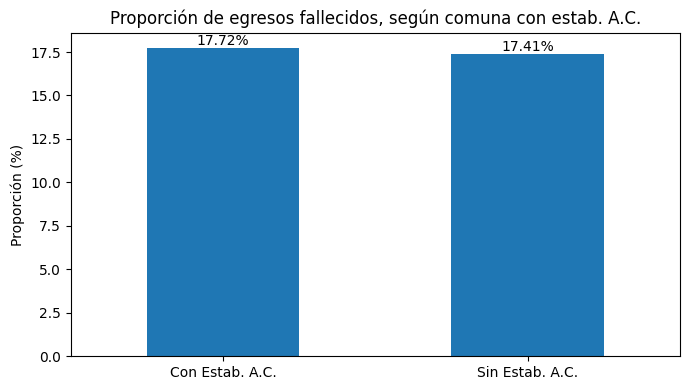

In [ ]:
# se muestran resultados finales
show_bar_proportions(
    tab1_prop["Fallecido"],
    "Proporción de egresos fallecidos, según comuna con estab. A.C."
)

Se observa un efecto estadísticamente significativo, pero minúsculo en la práctica, por lo que nuestras creencia fue desmentida y cambiamos el enfoque de la investigación a uno que apunta a diversas variables socioeconómicas, como se ve a continuación.

## Regresión Lineal: estudio de la desigualdad para los días de estancia hospitalaria
El modelo busca explicar los días de estancia, aplicado para nuestro dataset limitado a los pacientes de alta complejidad/alto peso GRD. En este caso, se incluyen variables demográficas, clínicas y socioeconómicas, con el objetivo de entender los efectos de la desigualdad para una estancia en establecimientos de salud pública.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
grd = pd.read_parquet('grd_procesado.parquet')

Se selecciona un cohorte de personas, con el objetivo de enfocar al modelo en una diversidad de casos, pero que sean relativamente equitativos, para tener datos más cercanos a una línea con la suficiente variedad para que el modelo no entrene solo con casos muy parecidos. En base a los siguiente 20 códigos GRD, se seleccionan 5 grupos de pacientes. <br>
<br>
Los dos primeros números representan la Categoría Diagnóstica Mayor (CDM), y se seleccionan los grupos: 04, 05, 06, 08 y 09 (ver referencia en https://www.osakidetza.euskadi.eus/contenidos/informacion/osk_publicaciones/es_publi/adjuntos/calidad/ManualAPGRDv.25.0.pdf) y el último dígito es la severidad, por lo que se eligen tres grupos con severidad 3, y dos grupos con severidad 2. 

In [2]:
grd['IR_29301_COD_GRD'].value_counts().head(20)

IR_29301_COD_GRD
041023    65232
041203    44861
061203    21166
041013    19593
051203    11144
051403    10430
011102     7695
081023     7463
174113     6077
081203     6015
091403     6013
061403     5917
174103     5440
091302     5231
011103     5135
081072     4720
071103     4385
091202     4311
071102     4239
051143     4169
Name: count, dtype: Int64

Se seleccione el cohorte y se modifican algunas variables para obtener mejor información con la regresión, considerando solo a los pacientes vivos con dias de estancia >= 1. Además, es claro que para un modelo de regresión los días de estanci

<Axes: >

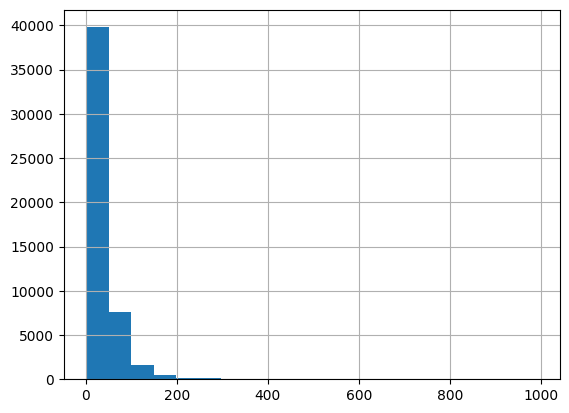

In [3]:
# se selecciona cohorte según criterios mencionados, para tener un cierto nivel de varianza pero no muy grande
top3grds = (grd[(grd['IR_29301_COD_GRD'].isin(['091302', '041013', '061203', '051403', '081072']))]).copy()

# se ignoran casos con 0 días de estancia por problemas matemáticos
top3grds = top3grds[top3grds['DIAS_ESTANCIA'] != 0]
# para conocer el intercepto del sexo específicamente, se considera solo hombre y mujer
top3grds['SEXO'] = top3grds['SEXO'].astype('string')
top3grds['SEXO'] = top3grds['SEXO'].replace({'DESCONOCIDO':np.nan})
top3grds.dropna(subset=['SEXO'],inplace=True)
top3grds.reset_index(drop=True, inplace=True)
# se descartan fallecidos, porque será muy obvio que reduce los días de estancia
top3grds = top3grds[(top3grds['TIPOALTA'] != 'FALLECIDO')]
# se considera la severidad como string, para que la categoria solo considere 2 y 3
top3grds['IR_29301_SEVERIDAD'] = top3grds['IR_29301_SEVERIDAD'].astype('string')
display(top3grds['DIAS_ESTANCIA'].hist(bins=20))

<Axes: >

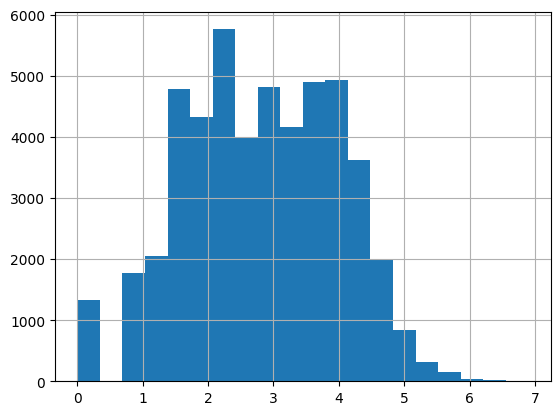

In [4]:
estancia_log = np.log(top3grds['DIAS_ESTANCIA'])
estancia_log.hist(bins=20)

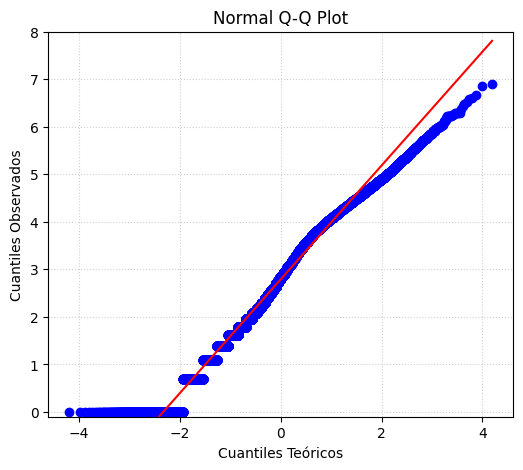

In [5]:
import scipy.stats as stats
# se crea el Q-Q plot usando stats.probplot con la variable a estudiar
plt.figure(figsize=(6, 5))
stats.probplot(estancia_log, dist="norm", plot=plt)

# se añaden textos y títulos
plt.title("Normal Q-Q Plot")
plt.xlabel("Cuantiles Teóricos")
plt.ylabel("Cuantiles Observados")
plt.ylim((-0.1,8))
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

Se utilizan las siguientes variables para realizar el modelo, utilizando Mínimos Cuadrados, segun la libreria de statsmodels.

In [7]:
# se importa la funcion
import statsmodels.formula.api as smf
# se otorga la formula y datos a estudiar
modelo = smf.ols(formula=
        "np.log(DIAS_ESTANCIA) ~ EDAD + C(SEXO) + IR_29301_PESO \
        + N_PROCEDIMIENTOS + N_COMORBILIDADES + IR_29301_SEVERIDAD + CRITICAS_1000HAB \
        + C(COMUNA_CON_ESTAB_AC) + POB_MULT_ESTAB",
        data=top3grds)
# se ajusta el modelo
resultado = modelo.fit()
# resultados detallados, gracias al resumen o summary de statsmodels
print(resultado.summary())

                              OLS Regression Results                             
Dep. Variable:     np.log(DIAS_ESTANCIA)   R-squared:                       0.569
Model:                               OLS   Adj. R-squared:                  0.569
Method:                    Least Squares   F-statistic:                     7300.
Date:                   Fri, 08 May 2026   Prob (F-statistic):               0.00
Time:                           12:08:45   Log-Likelihood:                -58988.
No. Observations:                  49787   AIC:                         1.180e+05
Df Residuals:                      49777   BIC:                         1.181e+05
Df Model:                              9                                         
Covariance Type:               nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

Se realiza el cálculo del Factor de Inflación de la Varianza (VIF en inglés), que es en la práctica un test de multicolinealidad, que observa la independencia de cada uno de los coeficientes. Con valores por sobre 5 o 10, dependiendo de la exigencia, se considera que la multicolinealidad es un problema y el coeficiente debe ser reconsiderado. Valores cercanos a 1 muestran independencia, lo que solidifica el efecto de los coeficientes y sus valores.

In [11]:
# se importa vif desde statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.tools.tools as sm
# se obtienen coeficientes del resultado del modelo
X = resultado.model.exog
# y sus nombres, para mostrar en resultados
nombres_variables = resultado.model.exog_names

# se añade constante requerida por sm para test VIF
X = sm.add_constant(X)

# se calcula el VIF para cada coeficiente
vif_data = pd.DataFrame()
vif_data["Variable"] = nombres_variables
vif_data["VIF"] = [variance_inflation_factor(X, i) for i in range(len(nombres_variables))]

pd.DataFrame(vif_data.iloc[1:])

,Variable,VIF
1,C(SEXO)[T.MUJER],1.014150
2,IR_29301_SEVERIDAD[T.3],1.229136
3,C(COMUNA_CON_ESTAB_AC)[T.1],1.081177
4,EDAD,1.069469
5,IR_29301_PESO,1.918285
6,N_PROCEDIMIENTOS,1.910713
7,N_COMORBILIDADES,1.836136
8,CRITICAS_1000HAB,1.322720
9,POB_MULT_ESTAB,1.244606


Todos los coeficientes tienen un valor menor a 2, con algunos muy cerca de 1, lo que es un resultado excelente y apoya nuestros resultados, incluso con un R cuadrado no tan alto, debido a la poca variabilidad de los datos.

Se realiza un Q-Q plot que muestra la distribución de los datos

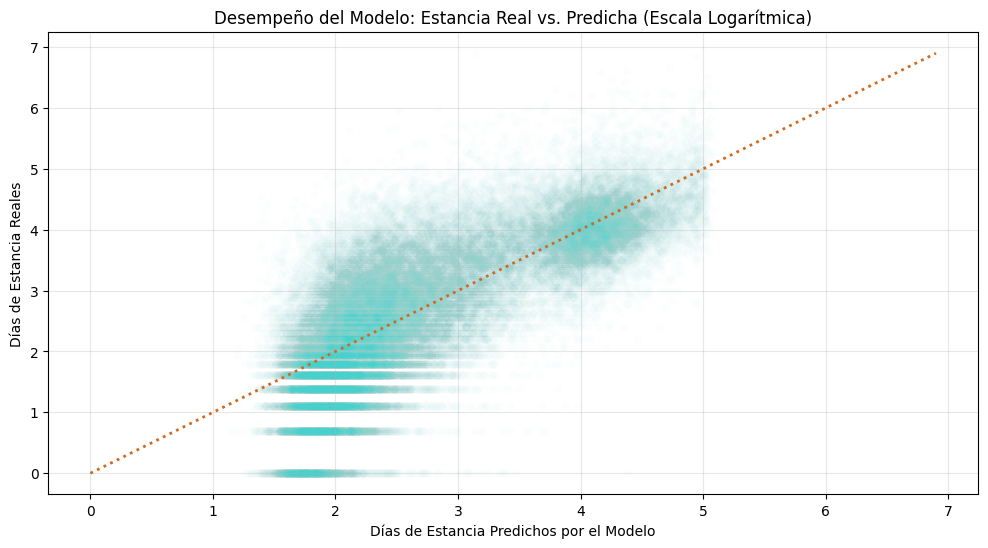

In [12]:
import seaborn as sns

# 1. Le pedimos al modelo que haga sus predicciones con los datos
predicciones_log = resultado.predict() 
valores_reales_log = estancia_log 

# 2. Creamos el gráfico
plt.figure(figsize=(12, 6))
sns.scatterplot(x=predicciones_log, y=valores_reales_log, alpha=0.01, color='mediumturquoise')

# 3. Dibujamos la línea roja de "predicción perfecta"
limite_min = min(predicciones_log.min(), valores_reales_log.min())
limite_max = max(predicciones_log.max(), valores_reales_log.max())
plt.plot([limite_min, limite_max], [limite_min, limite_max], color='chocolate', linewidth=2, linestyle=':')

plt.title('Desempeño del Modelo: Estancia Real vs. Predicha (Escala Logarítmica)')
plt.xlabel('Días de Estancia Predichos por el Modelo')
plt.ylabel('Días de Estancia Reales')
plt.grid(True, alpha=0.3)
plt.show()

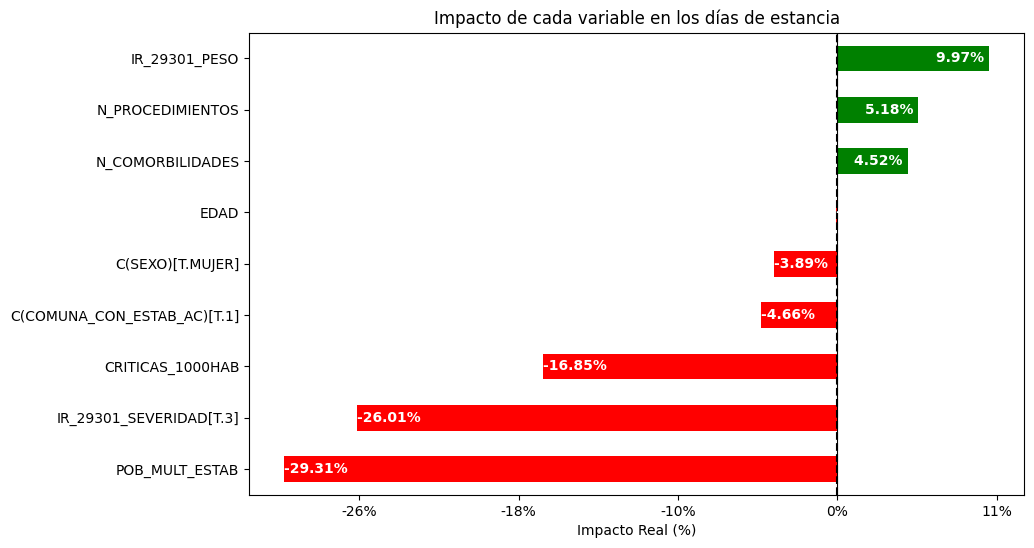

In [13]:
# no se considera el intercepto porque es un número muy grande y arruina la escala
coeficientes = resultado.params.drop('Intercept')

# se ordena de menor a mayor
coeficientes = coeficientes.sort_values()

# se crea el gráfico de barras
plt.figure(figsize=(10, 6))
coeficientes.plot(kind='barh', color=['red' if x < 0 else 'green' for x in coeficientes])

plt.axvline(x=0, color='black', linestyle='--') # linea del cero
plt.title('Impacto de cada variable en los días de estancia')
plt.xlabel('Efecto Porcentual Aproximado (Log)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
# ... (tu código anterior)
# Guardamos el gráfico en 'ax' para manipularlo
ax = coeficientes.plot(kind='barh', color=['red' if x < 0 else 'green' for x in coeficientes])

# Añadir las etiquetas dentro de las barras
for i, v in enumerate(coeficientes):
    pct = (np.exp(v) - 1) * 100
    
    # Si el valor es positivo, el texto se alinea a la derecha (dentro)
    # Si es negativo, se alinea a la izquierda (dentro)
    posicion_x = v 
    alineacion = 'right' if v > 0 else 'left'
    
    ax.text(posicion_x, i, f'{pct:.2f}% ', 
            va='center', 
            ha=alineacion, 
            color='white', # Color blanco para que resalte
            fontweight='bold',
            fontsize=10)

plt.axvline(x=0, color='black', linewidth=0.8)
# ... resto de tu código

# ... (el resto de tu código)
import matplotlib.ticker as mtick

# ... (tu código de creación del gráfico)
ax = coeficientes.plot(kind='barh', color=['red' if x < 0 else 'green' for x in coeficientes])

# Función para transformar la escala logarítmica a porcentaje en el eje X
def log_to_pct(x, pos):
    pct = (np.exp(x) - 1) * 100
    return f'{pct:.0f}%'

# Aplicamos el formateador al eje X
ax.xaxis.set_major_formatter(mtick.FuncFormatter(log_to_pct))

plt.xlabel('Impacto Real (%)')
# ... (resto de tus etiquetas y plt.show())

plt.show()